# Librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import statsmodels.formula.api as smf
from data_profiling import ProfileReport
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import math

In [2]:
df_original = pd.read_csv("LLAN0095_total.csv")


In [3]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949041 entries, 0 to 949040
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              949041 non-null  object 
 1   AMA               940452 non-null  float64
 2   AMV               940452 non-null  float64
 3   AVOA              940422 non-null  float64
 4   AVOV              940422 non-null  float64
 5   CT                940427 non-null  float64
 6   DeltaP            940372 non-null  float64
 7   Pd                940372 non-null  float64
 8   Pi                940372 non-null  float64
 9   PWF               0 non-null       float64
 10  RUN FREQ SETTING  366 non-null     float64
 11  RUN FREQ.         940417 non-null  float64
 12  RUN STATUS        947449 non-null  float64
 13  SD LAST REASON    416 non-null     float64
 14  Ti                940374 non-null  float64
 15  Tm                940373 non-null  float64
 16  VX                94

## Calculo caudal

In [209]:
df = df_original[['Date','AMA', 'AMV', 'AVOA', 'AVOV','RUN FREQ.','Pd', 'Pi','Ti','Tm','VX']]
# eliminar temperaturas valor 0
df = df[(df['Ti'] != 0) & (df['Tm'] != 0)]

# Eliminar los nan
df= df.dropna()

In [210]:
df_caudal = pd.read_excel('Caudal LLAN0095.xlsx')
df_caudal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 904 entries, 0 to 903
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   FECHA        904 non-null    datetime64[ns]
 1   CRUDP_PRORR  904 non-null    float64       
 2   GAS_PRORR    904 non-null    float64       
 3   AGUA_PRORR   904 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 28.4 KB


In [211]:
# Convertir las fechas a datetime
df['Date'] = pd.to_datetime(df['Date'])
df_caudal['FECHA'] = pd.to_datetime(df_caudal['FECHA'])

# Ordenar ambos DataFrames
df = df.sort_values('Date').reset_index(drop=True)
df_caudal = df_caudal.sort_values('FECHA').reset_index(drop=True)

df = pd.merge_asof(
    df,
    df_caudal[['FECHA', 'CRUDP_PRORR', 'GAS_PRORR', 'AGUA_PRORR']],
    left_on='Date',
    right_on='FECHA',
    direction='backward'
).drop(columns='FECHA')

### Calculo caudal

𝑄𝑝=(58847∗√3∗𝑉𝑚∗𝐼𝑚∗𝐹𝑃∗𝜂_𝑚∗𝜂_𝑝)/(746∗(𝑃𝐷𝑃−𝑃𝐼𝑃))

Vm= Voltaje Motor

Im= Corriente Motor

PDP= Presión de Descarga

PIP= Presión de Intake

FP= Factor de Potencia

Nm= Eficiencia de motor [manual o meter la curva del motor]

Np= Eficiencia de bomba [manual o meter la curva de la bomba

In [212]:
archivo = "Coeficientes.xlsx"

df_pump = pd.read_excel(
    archivo,
    sheet_name="Pump"
)

df_motor = pd.read_excel(
    archivo,
    sheet_name="Motor"
)

In [213]:
df_motor

,Manufacturer,Series,Type,Motor Length,Nameplate HP,Nameplate Voltage,Nameplate Current,R0,R1,R2,...,E1,E2,E3,E4,E5,Diameter,RPM,Shaft HP,Configuration,Obsolete
0,WSP,560,XT1-S,25.7,330.0,1950,102.500000,3497.000000,-63.320,-44.245000,...,-94.294000,361.450000,-611.590000,493.840000,-156.400000,5.620,3495,950,S,NaN
1,WSP,560,XT1-S,25.7,287.0,1567,92.596775,3497.000000,-63.320,-44.245000,...,-94.294000,361.450000,-611.590000,493.840000,-156.400000,5.620,3495,950,S,NaN
2,WSP,560,XT1-S,34.0,782.0,2773,160.800000,3497.000000,-63.320,-44.245000,...,-94.294000,361.450000,-611.590000,493.840000,-156.400000,5.620,3495,950,S,NaN
3,WSP,560,XT1-S,34.0,730.0,2844,155.000000,3497.000000,-63.320,-44.245000,...,-94.294000,361.450000,-611.590000,493.840000,-156.400000,5.620,3495,950,S,NaN
4,WSP,560,XT1-S,34.0,391.0,1454,160.800000,3497.000000,-63.320,-44.245000,...,-94.294000,361.450000,-611.590000,493.840000,-156.400000,5.620,3495,950,S,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,WSP,460,PMM,22.6,370.0,3360,57.100000,3600.000000,0.000,0.000000,...,592.312561,-1528.240690,1949.031344,-1222.774876,301.663940,4.606,3600,700,S,NaN
91,WSP,460,PMM,24.9,402.0,3870,67.000000,3600.000000,0.000,0.000000,...,592.312561,-1528.240690,1949.031344,-1222.774876,301.663940,4.606,3600,700,S,NaN
92,WSP,560,XT3-T,102.0,1173.0,4362,160.800000,3497.000000,-63.320,-44.245000,...,-94.294000,361.450000,-611.590000,493.840000,-156.400000,5.620,3495,1250,T,NaN
93,WSP,456,XT1-S,31.0,173.0,2347,46.200000,2678.183000,5485.689,-14259.410000,...,701.773400,-1267.423000,934.894000,-181.855800,-49.546000,4.560,3500,450,S,NaN


In [214]:
motor = df_motor[(df_motor['Type'] == 'XT1-S') & 
         (df_motor['Series'] == 560) & 
         (df_motor['Nameplate HP'] == 391.0) & 
         (df_motor['Nameplate Voltage'] == 3564) & 
         (df_motor['Nameplate Current'] == 92.6)]

motor

,Manufacturer,Series,Type,Motor Length,Nameplate HP,Nameplate Voltage,Nameplate Current,R0,R1,R2,...,E1,E2,E3,E4,E5,Diameter,RPM,Shaft HP,Configuration,Obsolete
9,WSP,560,XT1-S,34.0,391.0,3564,92.6,3497.0,-63.32,-44.245,...,-94.294,361.45,-611.59,493.84,-156.4,5.62,3495,950,S,NaN


In [215]:
pump = df_pump[(df_pump['Series'] == '400') & (df_pump['Model'] == 'WD1000ZX')]
pump

,Manufacturer,Series,Model,Min Rate,BEP Rate,Max Rate,Max Efficiency,Max Head,Max Graph Rate,H0,...,Pump OD,Standard Burst,High Burst,Shaft OD,Standard HP,High HP,Min Stages,Max Stages,Stage Increase,Max Thrust
53,WSP,400,WD1000ZX,500,1400,2000,0.66,31.0,2400.0,31.1754,...,4.0,6000,6000,0.688,125,250,NaN,NaN,NaN,NaN


In [216]:
LF = df['AVOA'] / motor ['Nameplate Current'].values[0]
FP =(motor['P0'].values[0] + 
    (motor['P1'].values[0] * LF) +  
    (motor['P2'].values[0] * LF**2) + 
    (motor['P3'].values[0] * LF**3) + 
    (motor['P4'].values[0] * LF**4) + 
    (motor['P5'].values[0] * LF**5)) /100

ef_m = (motor['E0'].values[0] +
        (motor['E1'].values[0] * LF) +
        (motor['E2'].values[0] * LF**2) +
        (motor['E3'].values[0] * LF**3) +
        (motor['E4'].values[0] * LF**4) +
        (motor['E5'].values[0] * LF**5))/100

ef_p = pump['Max Efficiency'].values[0]

In [217]:
def sqrt(x):
    return x ** 0.5

In [ ]:
df = df.copy()

# Caudal CALCULADO: formula fisica del ESP, usa Pd/Pi reales (solo para
# validar la formula contra el caudal medido -- NO se usa como feature de
# ningun modelo, porque en produccion no tendriamos Pd/Pi en tiempo real).
df['Caudal_calculado'] = (58847 * sqrt(3) * df['AVOV'] * df['AVOA'] * FP * ef_m * ef_p) / (746 * (df['Pd'] - df['Pi']))

# Caudal MEDIDO: prueba de produccion mensual (Caudal LLAN0095.xlsx, ya
# mergeada en 'CRUDP_PRORR'/'AGUA_PRORR' con merge_asof backward). Este es
# el que se usa de aqui en adelante (limpieza de outliers, lags, features de
# Ti/Tm) -- no depende de Pd/Pi, asi que no genera fuga.
df['Caudal'] = df['CRUDP_PRORR'] + df['AGUA_PRORR']

### Validar formula de Caudal calculado vs Caudal medido

In [ ]:
# --- Comparacion caudal calculado (formula) vs caudal medido (prueba mensual) ---
# Nota: 'Date' todavia es columna aca (el indice de fechas se arma mas abajo),
# asi que se usa df['Date'] explicitamente en vez de df.index.

# Serie temporal: el medido es un escalon (un solo valor por mes, por el
# merge_asof backward), el calculado varia dia a dia -- se grafican juntos
# para ver si el calculado oscila razonablemente alrededor del medido.
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Caudal_calculado'], label='Caudal calculado (formula)', alpha=0.6, linewidth=1)
ax.plot(df['Date'], df['Caudal'], label='Caudal medido (prueba mensual)', linewidth=2, color='black')
ax.set_xlabel('Fecha')
ax.set_ylabel('Caudal')
ax.set_title('Caudal calculado (formula ESP) vs Caudal medido (prueba de produccion mensual)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparacion mas justa: promediar el calculado por mes (misma resolucion que
# el medido) y comparar mes a mes, con metricas de error.
mes = df['Date'].dt.to_period('M')
comparacion_mensual = df.groupby(mes).agg(
    Caudal_calculado=('Caudal_calculado', 'mean'),
    Caudal_medido=('Caudal', 'first'),
).dropna()
comparacion_mensual.index = comparacion_mensual.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(comparacion_mensual.index, comparacion_mensual['Caudal_medido'], label='Medido (mensual)', marker='o', linewidth=2)
ax.plot(comparacion_mensual.index, comparacion_mensual['Caudal_calculado'], label='Calculado (promedio mensual)', marker='o', linewidth=2)
ax.set_xlabel('Mes')
ax.set_ylabel('Caudal')
ax.set_title('Caudal medido vs calculado, agregado mensual')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

error_abs = (comparacion_mensual['Caudal_calculado'] - comparacion_mensual['Caudal_medido']).abs()
error_pct = (error_abs / comparacion_mensual['Caudal_medido']) * 100
rmse_mensual = np.sqrt(mean_squared_error(comparacion_mensual['Caudal_medido'], comparacion_mensual['Caudal_calculado']))
correlacion = comparacion_mensual['Caudal_medido'].corr(comparacion_mensual['Caudal_calculado'])

print(f"RMSE mensual: {rmse_mensual:.2f}")
print(f"Error absoluto promedio: {error_abs.mean():.2f}")
print(f"Error porcentual promedio: {error_pct.mean():.2f}%")
print(f"Correlacion: {correlacion:.4f}")


<Axes: >

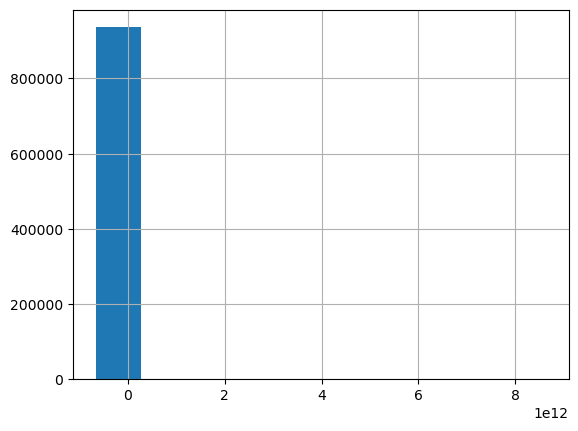

In [219]:
df['Caudal'].hist()

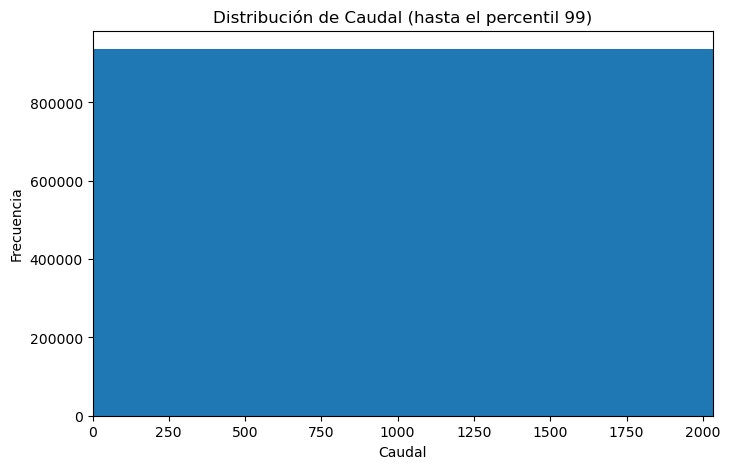

In [220]:
p99 = df['Caudal'].quantile(0.999)

plt.figure(figsize=(8,5))
plt.hist(df['Caudal'].dropna(), bins=50)
plt.xlim(0, p99)
plt.title('Distribución de Caudal (hasta el percentil 99)')
plt.xlabel('Caudal')
plt.ylabel('Frecuencia')
plt.show()

In [221]:
# Identificar outliers
print(df['Caudal'].describe(percentiles=[0.001, 0.01, 0.1, 0.90, 0.95, 0.99, 0.999]))

count    9.363360e+05
mean     1.625332e+07
std      1.241938e+10
min     -6.705202e+11
0.1%    -8.780071e+03
1%      -3.636477e+00
10%      9.257422e+02
50%      1.282169e+03
90%      1.343754e+03
95%      1.368696e+03
99%      1.737155e+03
99.9%    2.031868e+03
max      8.645727e+12
Name: Caudal, dtype: float64


In [222]:
# Contar los valores de caudal menores que cero
print("numeros de caudales menor que cero:", df.loc[df['Caudal'] < 0, 'Caudal'].count()) 

# convertir valores de caudal menor que cero a cero
df.loc[df['Caudal'] < 0, 'Caudal'] = 0

numeros de caudales menor que cero: 9536


In [223]:
# Eliminar filas donde caudal sea pequeno o grande
df = df[(df['Caudal'] >= 0) & (df['Caudal'] <= 2000)]

In [224]:
df = df.copy()
# convertir fecha
df['Date'] = pd.to_datetime(df['Date'])
# ordenar cronológicamente
df = df.sort_values('Date')
# colocar fecha como índice
df = df.set_index('Date')

FILTRO DE FECHAS - Gráficas de Pd, Ti, Tm, VX


Button(button_style='info', description='Actualizar Gráfica', style=ButtonStyle(), tooltip='Click para actuali…

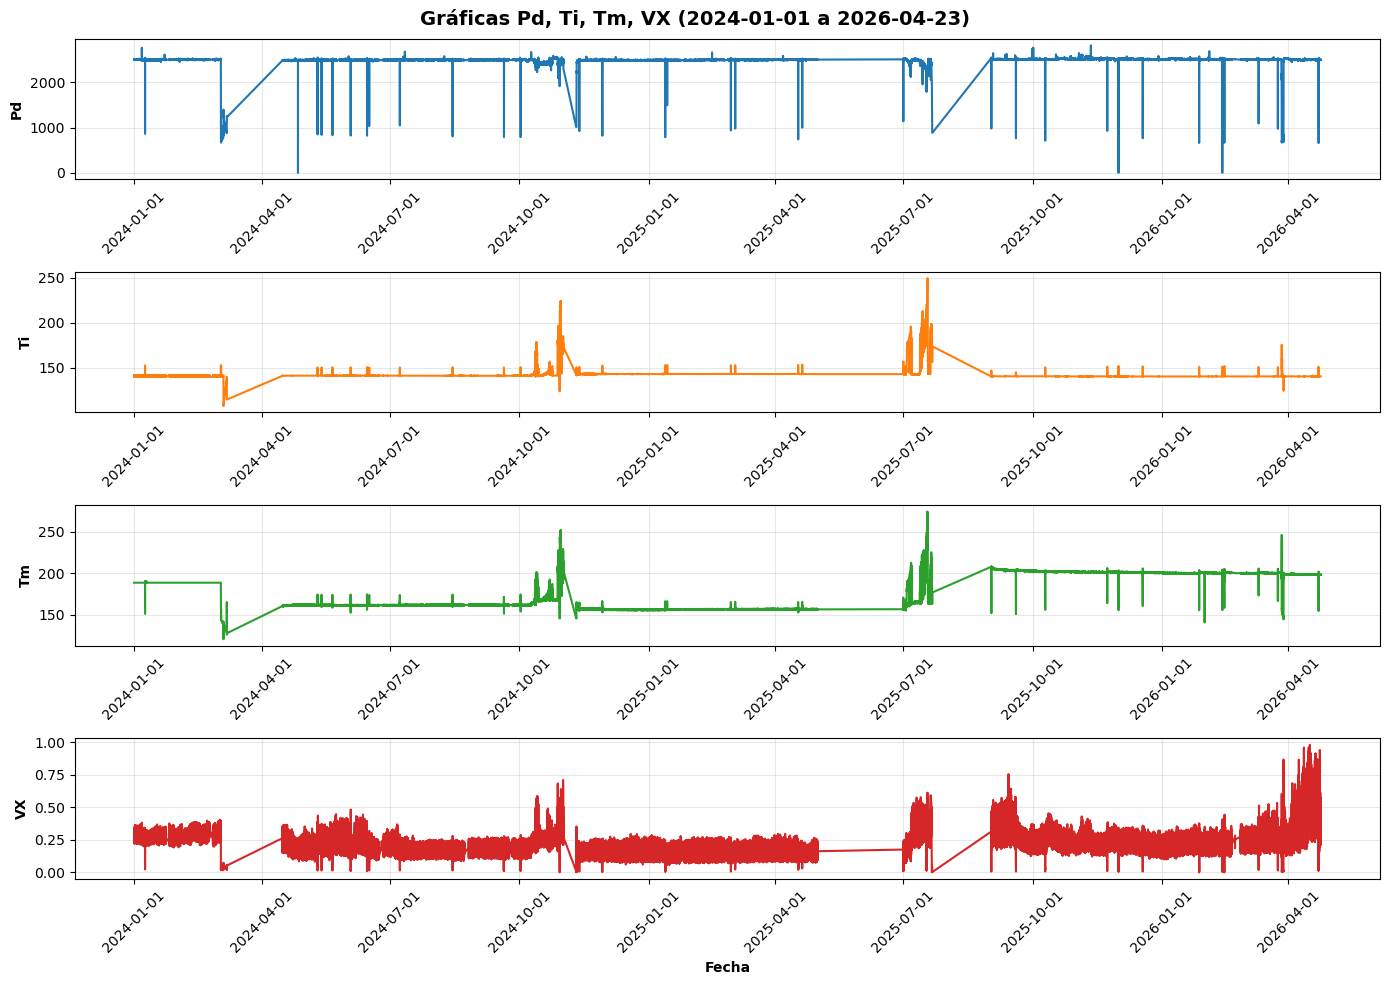

In [225]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.dates as mdates

# Obtener rango de fechas disponibles
fecha_min = df.index.min()
fecha_max = df.index.max()

# Crear widgets para filtro de fechas
date_picker_start = widgets.DatePicker(
    value=fecha_min.date(),
    description='Desde:',
    style={'description_width': '80px'}
)

date_picker_end = widgets.DatePicker(
    value=fecha_max.date(),
    description='Hasta:',
    style={'description_width': '80px'}
)

# Función para actualizar la gráfica
def plot_with_filter(start_date, end_date):
    # Filtrar datos por rango de fechas
    mask = (df.index.date >= start_date) & (df.index.date <= end_date)
    df_filtered = df[mask]
    
    if len(df_filtered) == 0:
        print("No hay datos en el rango de fechas seleccionado")
        return
    
    # Crear figura con 4 subplots
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    fig.suptitle(f'Gráficas Pd, Ti, Tm, VX ({start_date} a {end_date})', fontsize=14, fontweight='bold')
    
    # Pd
    axes[0].plot(df_filtered.index, df_filtered['Pd'], linewidth=1.5, color='#1f77b4')
    axes[0].set_ylabel('Pd', fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    # Ti
    axes[1].plot(df_filtered.index, df_filtered['Ti'], linewidth=1.5, color='#ff7f0e')
    axes[1].set_ylabel('Ti', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    # Tm
    axes[2].plot(df_filtered.index, df_filtered['Tm'], linewidth=1.5, color='#2ca02c')
    axes[2].set_ylabel('Tm', fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    # VX
    axes[3].plot(df_filtered.index, df_filtered['VX'], linewidth=1.5, color='#d62728')
    axes[3].set_ylabel('VX', fontweight='bold')
    axes[3].set_xlabel('Fecha', fontweight='bold')
    axes[3].grid(True, alpha=0.3)
    axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    # Rotar etiquetas de fecha
    for ax in axes:
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Crear botón para actualizar
button_update = widgets.Button(
    description='Actualizar Gráfica',
    button_style='info',
    tooltip='Click para actualizar la gráfica'
)

# Manejador del botón
def on_button_click(b):
    plot_with_filter(date_picker_start.value, date_picker_end.value)

button_update.on_click(on_button_click)

# Mostrar controles
print("FILTRO DE FECHAS - Gráficas de Pd, Ti, Tm, VX")
print("=" * 50)
display(widgets.HBox([date_picker_start, date_picker_end]))
display(button_update)

# Mostrar gráfica inicial con todos los datos
plot_with_filter(fecha_min.date(), fecha_max.date())

# Machine learning

In [226]:
df = df.copy()

df['AMA_lag_1']  = df['AMA'].shift(1)
df['AMA_lag_2']  = df['AMA'].shift(2)
df['AMA_lag_5']  = df['AMA'].shift(5)
df['AMA_lag_15'] = df['AMA'].shift(15)
df['AMA_lag_30'] = df['AMA'].shift(30)
df['AMA_mean_30'] = df['AMA'].rolling(30).mean()
df['AMA_std_30'] = df['AMA'].rolling(30).std()

df['AVOV_lag_1']  = df['AVOV'].shift(1)
df['AVOV_lag_2']  = df['AVOV'].shift(2)
df['AVOV_lag_5']  = df['AVOV'].shift(5)
df['AVOV_lag_15'] = df['AVOV'].shift(15)
df['AVOV_lag_30'] = df['AVOV'].shift(30)
df['AVOV_mean_30'] = df['AVOV'].rolling(30).mean()
df['AVOV_std_30'] = df['AVOV'].rolling(30).std()

df['Caudal_lag_1']  = df['Caudal'].shift(1)
df['Caudal_lag_2']  = df['Caudal'].shift(2)
df['Caudal_lag_5']  = df['Caudal'].shift(5)
df['Caudal_lag_15'] = df['Caudal'].shift(15)
df['Caudal_lag_30'] = df['Caudal'].shift(30)
df['Caudal_mean_30'] = df['Caudal'].rolling(30).mean()
df['Caudal_std_30'] = df['Caudal'].rolling(30).std()

df['Ti_lag_31']  = df['Ti'].shift(31)
df['Ti_lag_32']  = df['Ti'].shift(32)
df['Ti_lag_35']  = df['Ti'].shift(35)
df['Ti_lag_45'] = df['Ti'].shift(45)
df['Ti_lag_60'] = df['Ti'].shift(60)
df['Ti_mean_31_60'] = df['Ti'].shift(30).rolling(30).mean()
df['Ti_std_31_60'] = df['Ti'].shift(30).rolling(30).std()

df['Tm_lag_31']  = df['Tm'].shift(31)
df['Tm_lag_32']  = df['Tm'].shift(32)
df['Tm_lag_35']  = df['Tm'].shift(35)
df['Tm_lag_45'] = df['Tm'].shift(45)
df['Tm_lag_60'] = df['Tm'].shift(60)
df['Tm_mean_31_60'] = df['Tm'].shift(30).rolling(30).mean()
df['Tm_std_31_60'] = df['Tm'].shift(30).rolling(30).std()

df['VX_lag_31']  = df['VX'].shift(31)
df['VX_lag_32']  = df['VX'].shift(32)
df['VX_lag_35']  = df['VX'].shift(35)
df['VX_lag_45'] = df['VX'].shift(45)
df['VX_lag_60'] = df['VX'].shift(60)
df['VX_mean_31_60'] = df['VX'].shift(30).rolling(30).mean()
df['VX_std_31_60'] = df['VX'].shift(30).rolling(30).std()


df.dropna(inplace=True)

In [227]:
# Contar NaN por columna
nan_por_columna = df.isna().sum()

print(nan_por_columna)

AMA               0
AMV               0
AVOA              0
AVOV              0
RUN FREQ.         0
Pd                0
Pi                0
Ti                0
Tm                0
VX                0
CRUDP_PRORR       0
GAS_PRORR         0
AGUA_PRORR        0
Caudal            0
AMA_lag_1         0
AMA_lag_2         0
AMA_lag_5         0
AMA_lag_15        0
AMA_lag_30        0
AMA_mean_30       0
AMA_std_30        0
AVOV_lag_1        0
AVOV_lag_2        0
AVOV_lag_5        0
AVOV_lag_15       0
AVOV_lag_30       0
AVOV_mean_30      0
AVOV_std_30       0
Caudal_lag_1      0
Caudal_lag_2      0
Caudal_lag_5      0
Caudal_lag_15     0
Caudal_lag_30     0
Caudal_mean_30    0
Caudal_std_30     0
Ti_lag_31         0
Ti_lag_32         0
Ti_lag_35         0
Ti_lag_45         0
Ti_lag_60         0
Ti_mean_31_60     0
Ti_std_31_60      0
Tm_lag_31         0
Tm_lag_32         0
Tm_lag_35         0
Tm_lag_45         0
Tm_lag_60         0
Tm_mean_31_60     0
Tm_std_31_60      0
VX_lag_31         0


In [228]:
df

,AMA,AMV,AVOA,AVOV,RUN FREQ.,Pd,Pi,Ti,Tm,VX,...,Tm_lag_60,Tm_mean_31_60,Tm_std_31_60,VX_lag_31,VX_lag_32,VX_lag_35,VX_lag_45,VX_lag_60,VX_mean_31_60,VX_std_31_60
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-01 01:00:30,24.283,1718.4,130.4,320.0,42.0,2501.1,628.7,141.8,188.6,0.245,...,188.6,188.600000,0.000000,0.276,0.301,0.289,0.256,0.326,0.278033,0.023532
2024-01-01 01:01:34,24.283,1718.4,130.4,320.0,42.0,2502.4,627.9,141.8,188.6,0.317,...,188.6,188.600000,0.000000,0.277,0.276,0.303,0.268,0.298,0.277233,0.023236
2024-01-01 01:02:30,24.264,1718.4,130.3,320.0,42.0,2502.4,627.9,141.8,188.6,0.317,...,188.6,188.600000,0.000000,0.274,0.277,0.266,0.313,0.267,0.278267,0.023453
2024-01-01 01:03:34,24.283,1718.4,130.4,320.0,42.0,2497.4,628.5,140.0,188.6,0.312,...,188.6,188.600000,0.000000,0.298,0.274,0.301,0.242,0.310,0.277900,0.023022
2024-01-01 01:04:30,24.302,1718.4,130.5,320.0,42.0,2497.4,628.5,140.0,188.6,0.312,...,188.6,188.600000,0.000000,0.299,0.298,0.276,0.259,0.272,0.277867,0.023032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-23 21:38:30,24.680,1843.7,127.1,358.0,45.0,2494.8,599.5,140.4,198.2,0.293,...,198.2,198.186667,0.077608,0.352,0.462,0.477,0.329,0.364,0.357033,0.065356
2026-04-23 21:39:32,24.738,1843.7,127.4,358.0,45.0,2494.7,599.2,140.5,198.4,0.275,...,198.2,198.183333,0.079148,0.343,0.352,0.293,0.286,0.282,0.357300,0.065055
2026-04-23 21:40:30,24.757,1843.7,127.5,358.0,45.0,2494.0,599.1,140.5,198.2,0.336,...,198.2,198.183333,0.079148,0.290,0.343,0.340,0.427,0.348,0.359900,0.066219


In [229]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

# Pd 

In [22]:
features = [
    # variables originales
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'RUN FREQ.',
    # AMA temporal
    'AMA_lag_1',
    'AMA_lag_2',
    'AMA_lag_5',
    'AMA_lag_15',
    'AMA_lag_30',
    'AMA_mean_30',
    'AMA_std_30',
    # AVOV temporal
    'AVOV_lag_1',
    'AVOV_lag_2',
    'AVOV_lag_5',
    'AVOV_lag_15',
    'AVOV_lag_30',
    'AVOV_mean_30',
    'AVOV_std_30'
]

target = 'Pd'

df_model = df[features + [target]].copy()
X = df_model[features]
y = df_model[target]

In [23]:
# Garantizar que los datos estén ordenados por fecha
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("="*60)

print("TRAIN")

print(f"Inicio : {X_train.index.min()}")
print(f"Fin    : {X_train.index.max()}")
print(f"Datos  : {len(X_train):,}")

print()

print("TEST")

print(f"Inicio : {X_test.index.min()}")
print(f"Fin    : {X_test.index.max()}")
print(f"Datos  : {len(X_test):,}")

print("="*60)

TRAIN
Inicio : 2024-01-01 01:00:30
Fin    : 2025-12-06 09:46:30
Datos  : 749,022

TEST
Inicio : 2025-12-06 09:47:30
Fin    : 2026-04-23 21:42:30
Datos  : 187,256


### Regresion lineal

In [24]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random Forest

In [25]:
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=20,
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST
     Feature  Importance
  AVOV_lag_5    0.192636
AVOV_mean_30    0.178587
  AVOV_lag_2    0.122642
 AVOV_lag_15    0.108479
  AVOV_lag_1    0.099740
   AMA_lag_5    0.070353
   RUN FREQ.    0.051987
  AMA_lag_15    0.034372
         AMV    0.033554
        AVOV    0.019909
   AMA_lag_1    0.017773
 AMA_mean_30    0.016011
  AMA_std_30    0.014442
 AVOV_std_30    0.009050
   AMA_lag_2    0.008903
        AVOA    0.007709
  AMA_lag_30    0.005565
 AVOV_lag_30    0.004177
         AMA    0.004110


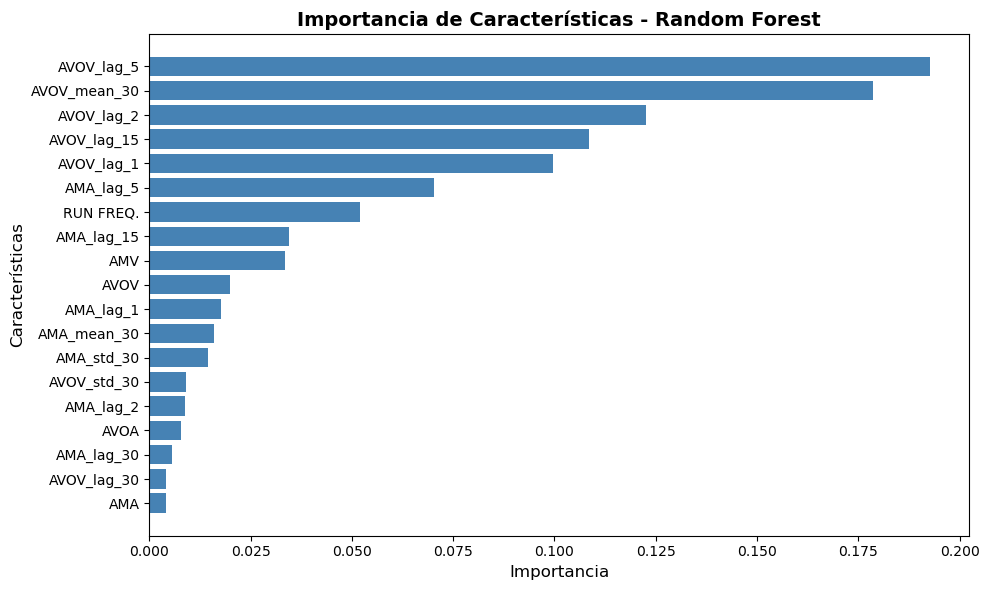


PARTICIPACIÓN PORCENTUAL:
     Feature  Participacion %
  AVOV_lag_5            19.26
AVOV_mean_30            17.86
  AVOV_lag_2            12.26
 AVOV_lag_15            10.85
  AVOV_lag_1             9.97
   AMA_lag_5             7.04
   RUN FREQ.             5.20
  AMA_lag_15             3.44
         AMV             3.36
        AVOV             1.99
   AMA_lag_1             1.78
 AMA_mean_30             1.60
  AMA_std_30             1.44
 AVOV_std_30             0.90
   AMA_lag_2             0.89
        AVOA             0.77
  AMA_lag_30             0.56
 AVOV_lag_30             0.42
         AMA             0.41


In [26]:
# Importancia de las características en el modelo Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST")
print("=" * 50)
print(feature_importance.to_string(index=False))
print("=" * 50)

# Gráfico de importancia
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.title('Importancia de Características - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Participación porcentual
feature_importance['Participacion %'] = (feature_importance['Importance'] / feature_importance['Importance'].sum() * 100).round(2)
print("\nPARTICIPACIÓN PORCENTUAL:")
print(feature_importance[['Feature', 'Participacion %']].to_string(index=False))

### Gradient Boosting

In [27]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

### XGBRegresorr

In [28]:
# Modelo
xgb = XGBRegressor(
    subsample=0.8,
    reg_lambda=2,
    reg_alpha=0.1,
    n_estimators=200,
    min_child_weight=1,
    max_depth=3,
    learning_rate=0.01,
    gamma=0.3,
    colsample_bytree=0.7,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Entrenar
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

### LightGBM

In [29]:
# Modelo
lgbm = LGBMRegressor(
    boosting_type='gbdt',
    n_estimators=200,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=2,
    random_state=42,
    n_jobs=-1
)

# Entrenar
lgbm.fit(X_train, y_train)
# Predicción
y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007249 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3431
[LightGBM] [Info] Number of data points in the train set: 749022, number of used features: 19
[LightGBM] [Info] Start training from score 2478.699086
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

### Catboost

In [30]:
# Modelo
cat = CatBoostRegressor(
    iterations=200,
    learning_rate=0.01,
    depth=3,
    subsample=0.8,
    l2_leaf_reg=2,
    random_seed=42,
    loss_function='RMSE',
    verbose=0
)

# Entrenar
cat.fit(X_train, y_train)
# Predicción
y_pred_cat = cat.predict(X_test)

### Evaluacion

In [31]:


evaluar(y_test, y_pred_lr,  "Linear Regression")
evaluar(y_test, y_pred_rf,  "Random Forest")
evaluar(y_test, y_pred_gbr, "Gradient Boosting")
evaluar(y_test, y_pred_xgb, "XGBoost")
evaluar(y_test, y_pred_lgbm, "LightGBM")
evaluar(y_test, y_pred_cat, "CatBoost")

Linear Regression -> RMSE: 95.663 | R2: 0.730
Random Forest -> RMSE: 63.209 | R2: 0.882
Gradient Boosting -> RMSE: 46.044 | R2: 0.937
XGBoost -> RMSE: 44.047 | R2: 0.943
LightGBM -> RMSE: 44.557 | R2: 0.941
CatBoost -> RMSE: 45.451 | R2: 0.939


In [32]:
# Crear tabla de evaluación
resultados = []

modelos = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm,
    "CatBoost": y_pred_cat
}

for nombre, predicciones in modelos.items():
    mse = mean_squared_error(y_test, predicciones)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    resultados.append({
        "Modelo": nombre,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R² Score": round(r2, 4),
        "MSE": round(mse, 4)
    })

tabla_evaluacion = pd.DataFrame(resultados)
tabla_evaluacion

,Modelo,RMSE,MAE,R² Score,MSE
0,Linear Regression,95.6631,19.5425,0.7297,9151.4230
1,Random Forest,63.2094,47.5955,0.8820,3995.4298
2,Gradient Boosting,46.0441,11.9440,0.9374,2120.0629
3,XGBoost,44.0468,11.1254,0.9427,1940.1192
4,LightGBM,44.5571,10.7187,0.9414,1985.3307
5,CatBoost,45.4511,12.3751,0.9390,2065.8002


### Grafica

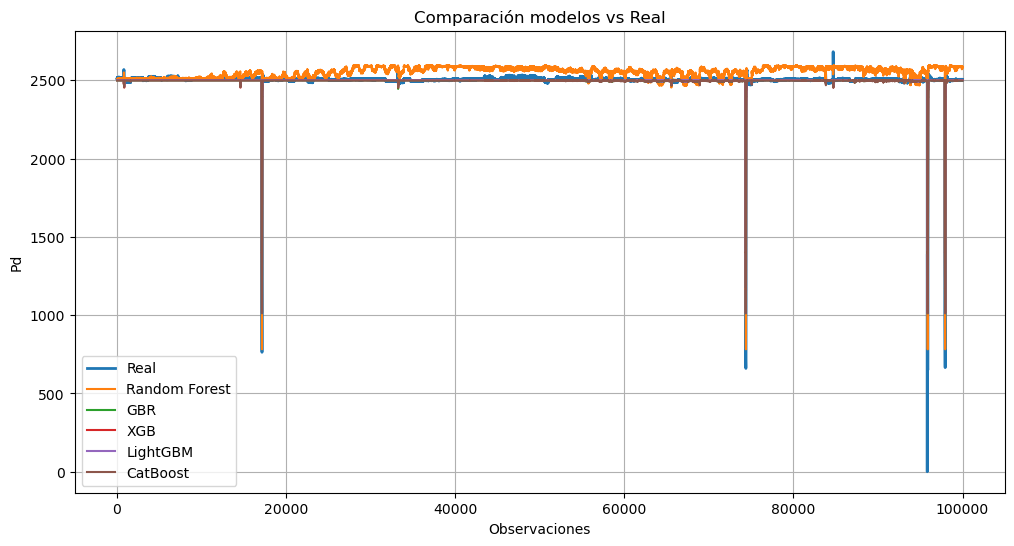

In [33]:
plt.figure(figsize=(12,6))

window_max=100000

plt.plot(y_test.values[:window_max], label='Real', linewidth=2)
#plt.plot(y_pred_lr[:window_max], label='Linear')
plt.plot(y_pred_rf[:window_max], label='Random Forest')
plt.plot(y_pred_gbr[:window_max], label='GBR')
plt.plot(y_pred_xgb[:window_max], label='XGB')
plt.plot(y_pred_lgbm[:window_max], label='LightGBM')
plt.plot(y_pred_cat[:window_max], label='CatBoost')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Observaciones')
plt.ylabel('Pd')
plt.grid(True)

plt.show()

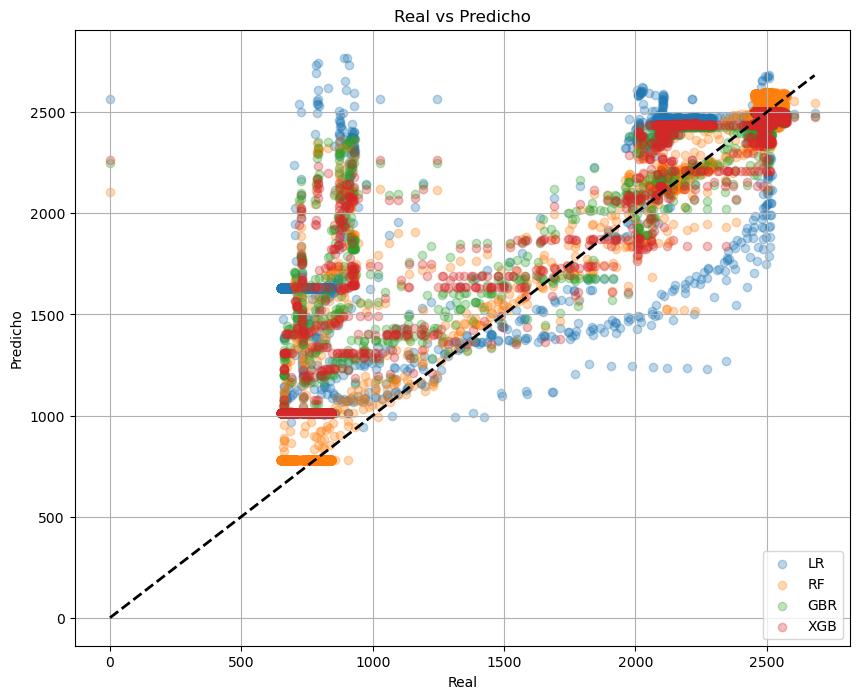

In [34]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='LR')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='RF')
#plt.scatter(y_test, y_pred_svr, alpha=0.3, label='SVR')
plt.scatter(y_test, y_pred_gbr, alpha=0.3, label='GBR')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGB')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)

plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.grid(True)

plt.show()

In [35]:
print("Fecha inicial:", y_test.index.min())
print("Fecha final:", y_test.index.max())

Fecha inicial: 2025-12-06 09:47:30
Fecha final: 2026-04-23 21:42:30


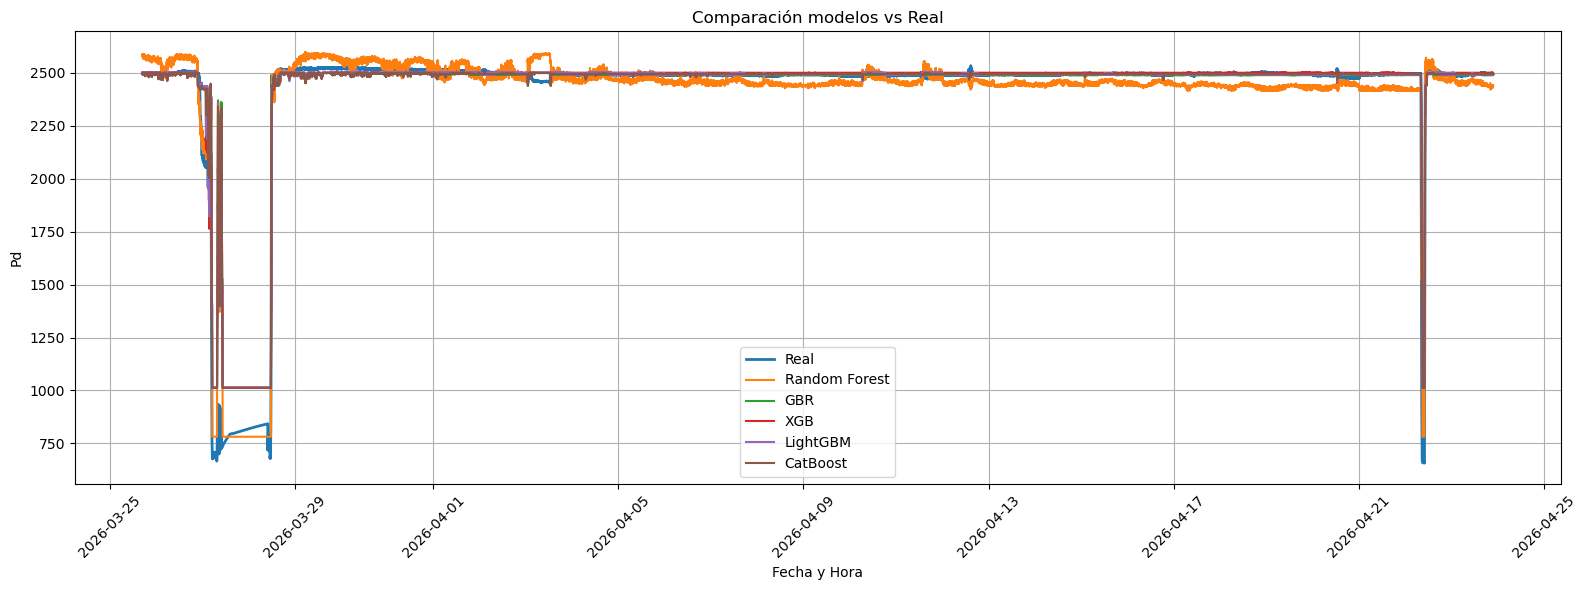

In [36]:
inicio = '2026-03-25 17:00:00'
fin    = '2026-04-30 20:00:00'

mask = (y_test.index >= inicio) & (y_test.index <= fin)

plt.figure(figsize=(16,6))

plt.plot(y_test.index[mask], y_test[mask], label='Real', linewidth=2)
plt.plot(y_test.index[mask], y_pred_rf[mask], label='Random Forest')
plt.plot(y_test.index[mask], y_pred_gbr[mask], label='GBR')
plt.plot(y_test.index[mask], y_pred_xgb[mask], label='XGB')
# plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_lgbm[mask], label='LightGBM')
plt.plot(y_test.index[mask], y_pred_cat[mask], label='CatBoost')




plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Fecha y Hora')
plt.ylabel('Pd')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Ti

In [230]:
features = [
    # variables originales
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'RUN FREQ.',
    # AMA temporal
    'AMA_lag_1',
    'AMA_lag_2',
    'AMA_lag_5',
    'AMA_lag_15',
    'AMA_lag_30',
    'AMA_mean_30',
    'AMA_std_30',
    # AVOV temporal
    'AVOV_lag_1',
    'AVOV_lag_2',
    'AVOV_lag_5',
    'AVOV_lag_15',
    'AVOV_lag_30',
    'AVOV_mean_30',
    'AVOV_std_30',
    # Caudal
    'Caudal_lag_1',
    'Caudal_lag_2',
    'Caudal_lag_5',
    'Caudal_lag_15',
    'Caudal_lag_30',
    'Caudal_mean_30',
    'Caudal_std_30',    
]

target = 'Ti'

df_model = df[features + [target]].copy()
X = df_model[features]
y = df_model[target]

In [231]:
# Garantizar que los datos estén ordenados por fecha
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("="*60)

print("TRAIN")

print(f"Inicio : {X_train.index.min()}")
print(f"Fin    : {X_train.index.max()}")
print(f"Datos  : {len(X_train):,}")

print()

print("TEST")

print(f"Inicio : {X_test.index.min()}")
print(f"Fin    : {X_test.index.max()}")
print(f"Datos  : {len(X_test):,}")

print("="*60)

TRAIN
Inicio : 2024-01-01 01:00:30
Fin    : 2025-12-06 10:57:34
Datos  : 748,152

TEST
Inicio : 2025-12-06 10:58:30
Fin    : 2026-04-23 21:42:30
Datos  : 187,038


### Regresion lineal

In [232]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random Forest

In [233]:
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=10,
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST
       Feature  Importance
    AVOV_lag_5    0.085143
    AVOV_lag_1    0.069691
   AMA_mean_30    0.059657
    AVOV_lag_2    0.058965
     RUN FREQ.    0.049157
    AMA_std_30    0.048622
 Caudal_std_30    0.044937
Caudal_mean_30    0.043490
   AVOV_lag_15    0.043313
          AVOV    0.040777
   AVOV_lag_30    0.040265
     AMA_lag_1    0.038959
           AMV    0.038294
  AVOV_mean_30    0.037517
          AVOA    0.034963
     AMA_lag_5    0.034344
     AMA_lag_2    0.033331
  Caudal_lag_1    0.030126
           AMA    0.029217
  Caudal_lag_2    0.027477
  Caudal_lag_5    0.024932
    AMA_lag_30    0.024131
    AMA_lag_15    0.023762
 Caudal_lag_15    0.022449
 Caudal_lag_30    0.010918
   AVOV_std_30    0.005563


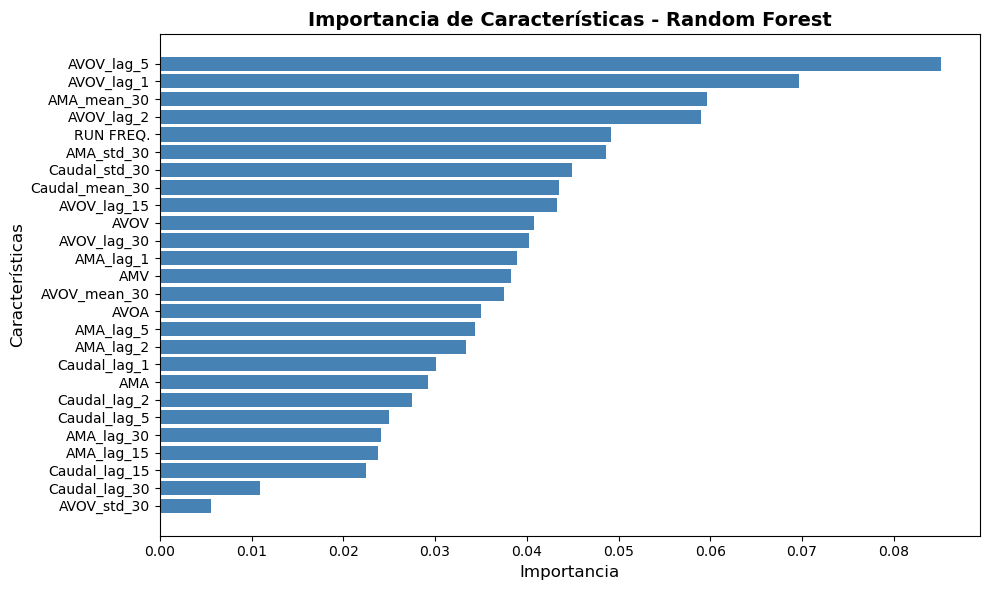


PARTICIPACIÓN PORCENTUAL:
       Feature  Participacion %
    AVOV_lag_5             8.51
    AVOV_lag_1             6.97
   AMA_mean_30             5.97
    AVOV_lag_2             5.90
     RUN FREQ.             4.92
    AMA_std_30             4.86
 Caudal_std_30             4.49
Caudal_mean_30             4.35
   AVOV_lag_15             4.33
          AVOV             4.08
   AVOV_lag_30             4.03
     AMA_lag_1             3.90
           AMV             3.83
  AVOV_mean_30             3.75
          AVOA             3.50
     AMA_lag_5             3.43
     AMA_lag_2             3.33
  Caudal_lag_1             3.01
           AMA             2.92
  Caudal_lag_2             2.75
  Caudal_lag_5             2.49
    AMA_lag_30             2.41
    AMA_lag_15             2.38
 Caudal_lag_15             2.24
 Caudal_lag_30             1.09
   AVOV_std_30             0.56


In [234]:
# Importancia de las características en el modelo Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST")
print("=" * 50)
print(feature_importance.to_string(index=False))
print("=" * 50)

# Gráfico de importancia
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.title('Importancia de Características - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Participación porcentual
feature_importance['Participacion %'] = (feature_importance['Importance'] / feature_importance['Importance'].sum() * 100).round(2)
print("\nPARTICIPACIÓN PORCENTUAL:")
print(feature_importance[['Feature', 'Participacion %']].to_string(index=False))

### Gradient Boosting

In [235]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

### XGBRegresorr

In [236]:
# Modelo
xgb = XGBRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=None,
    max_depth=7,
    learning_rate=0.01,
    random_state=42,
    n_jobs=-1
)
# Entrenar
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

c:\Users\lggom\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:30:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### LightGBM

In [237]:
# Modelo
lgbm = LGBMRegressor(
    subsample=0.8,
    reg_lambda=0,
    reg_alpha=0,
    num_leaves=20,
    n_estimators=100,
    min_child_weight=5,
    min_child_samples=20,
    max_depth=5,
    learning_rate=0.05,
    feature_fraction=0.7,
    colsample_bytree=1.0,
    bagging_fraction=0.7,
    random_state=42,
    n_jobs=-1
)
# Entrenar
lgbm.fit(X_train, y_train)
# Predicción
y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,031614 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5141
[LightGBM] [Info] Number of data points in the train set: 748152, number of used features: 26
[LightGBM] [Info] Start training from score 142,854917
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Curre

### Catboost

In [238]:
# Modelo
cat = CatBoostRegressor(
    subsample=0.9,
    min_child_samples=20,
    learning_rate=0.1,
    l2_leaf_reg=10,
    iterations=500,
    depth=3,
    colsample_bylevel=0.7,
    border_count=32
)

# Entrenar
cat.fit(X_train, y_train)
# Predicción
y_pred_cat = cat.predict(X_test)

0:	learn: 6.9796952	total: 25.1ms	remaining: 12.5s
1:	learn: 6.6556356	total: 47.9ms	remaining: 11.9s
2:	learn: 6.3797837	total: 69.8ms	remaining: 11.6s
3:	learn: 6.1394505	total: 93.4ms	remaining: 11.6s
4:	learn: 5.9364708	total: 116ms	remaining: 11.4s
5:	learn: 5.7637425	total: 140ms	remaining: 11.5s
6:	learn: 5.6161543	total: 163ms	remaining: 11.4s
7:	learn: 5.4847495	total: 186ms	remaining: 11.5s
8:	learn: 5.3714777	total: 210ms	remaining: 11.4s
9:	learn: 5.2147319	total: 233ms	remaining: 11.4s
10:	learn: 5.0770635	total: 257ms	remaining: 11.4s
11:	learn: 4.9966991	total: 280ms	remaining: 11.4s
12:	learn: 4.8862167	total: 303ms	remaining: 11.4s
13:	learn: 4.8238769	total: 325ms	remaining: 11.3s
14:	learn: 4.7348003	total: 349ms	remaining: 11.3s
15:	learn: 4.6813865	total: 371ms	remaining: 11.2s
16:	learn: 4.5992894	total: 393ms	remaining: 11.2s
17:	learn: 4.5373176	total: 415ms	remaining: 11.1s
18:	learn: 4.5005067	total: 438ms	remaining: 11.1s
19:	learn: 4.4604777	total: 463ms	rem

### Evaluacion

In [239]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

evaluar(y_test, y_pred_lr,  "Linear Regression")
evaluar(y_test, y_pred_rf,  "Random Forest")
evaluar(y_test, y_pred_gbr, "Gradient Boosting")
evaluar(y_test, y_pred_xgb, "XGBoost")
evaluar(y_test, y_pred_lgbm, "LightGBM")
evaluar(y_test, y_pred_cat, "CatBoost")

Linear Regression -> RMSE: 2.364 | R2: -4.299
Random Forest -> RMSE: 1.336 | R2: -0.693
Gradient Boosting -> RMSE: 1.180 | R2: -0.321
XGBoost -> RMSE: 0.859 | R2: 0.300
LightGBM -> RMSE: 0.834 | R2: 0.341
CatBoost -> RMSE: 0.958 | R2: 0.129


In [240]:
# Crear tabla de evaluación
resultados = []

modelos = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm,
    "CatBoost": y_pred_cat
}

for nombre, predicciones in modelos.items():
    mse = mean_squared_error(y_test, predicciones)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    resultados.append({
        "Modelo": nombre,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R² Score": round(r2, 4),
        "MSE": round(mse, 4)
    })

tabla_evaluacion = pd.DataFrame(resultados)
tabla_evaluacion

,Modelo,RMSE,MAE,R² Score,MSE
0,Linear Regression,2.3637,1.9528,-4.2986,5.5870
1,Random Forest,1.3360,0.9870,-0.6926,1.7848
2,Gradient Boosting,1.1800,0.9315,-0.3205,1.3924
3,XGBoost,0.8593,0.3408,0.2998,0.7383
4,LightGBM,0.8337,0.2200,0.3409,0.6950
5,CatBoost,0.9584,0.5393,0.1289,0.9185


### Grafica

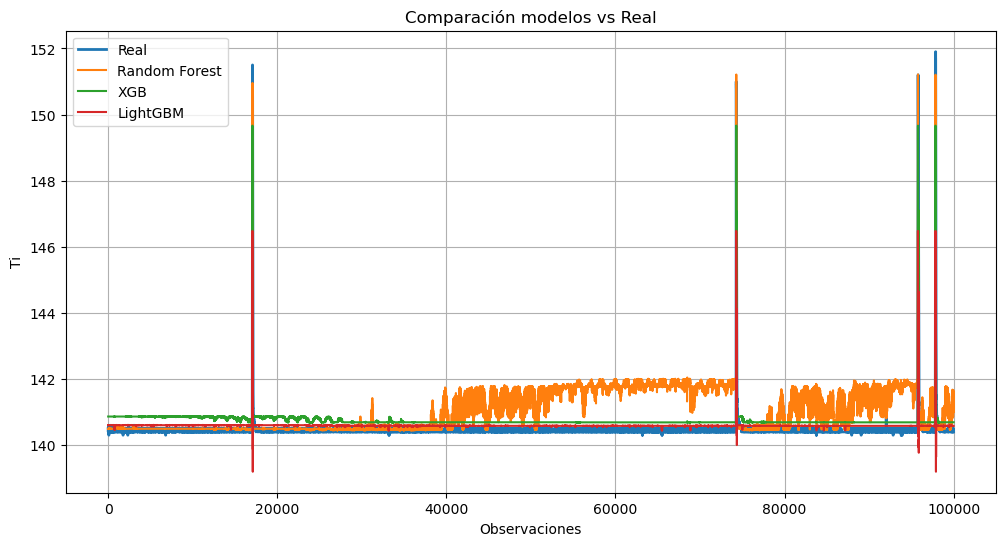

In [241]:
plt.figure(figsize=(12,6))

window_max=100000

plt.plot(y_test.values[:window_max], label='Real', linewidth=2)
#plt.plot(y_pred_lr[:window_max], label='Linear')
plt.plot(y_pred_rf[:window_max], label='Random Forest')
#plt.plot(y_pred_gbr[:window_max], label='GBR')
plt.plot(y_pred_xgb[:window_max], label='XGB')
plt.plot(y_pred_lgbm[:window_max], label='LightGBM')
#plt.plot(y_pred_cat[:window_max], label='CatBoost')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Observaciones')
plt.ylabel('Ti')
plt.grid(True)

plt.show()

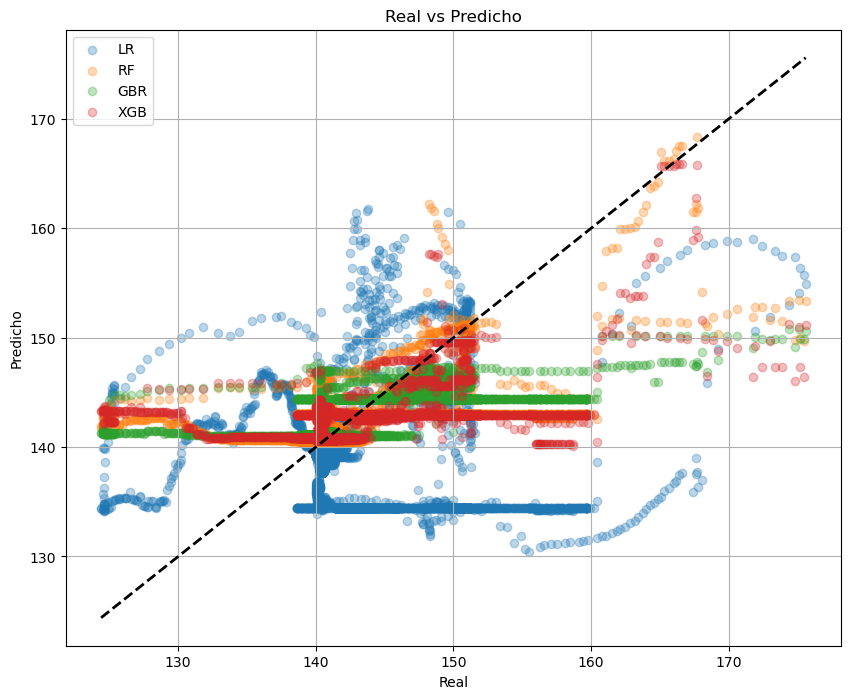

In [242]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='LR')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='RF')
#plt.scatter(y_test, y_pred_svr, alpha=0.3, label='SVR')
plt.scatter(y_test, y_pred_gbr, alpha=0.3, label='GBR')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGB')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)

plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.grid(True)

plt.show()

In [243]:
print("Fecha inicial:", y_test.index.min())
print("Fecha final:", y_test.index.max())

Fecha inicial: 2025-12-06 10:58:30
Fecha final: 2026-04-23 21:42:30


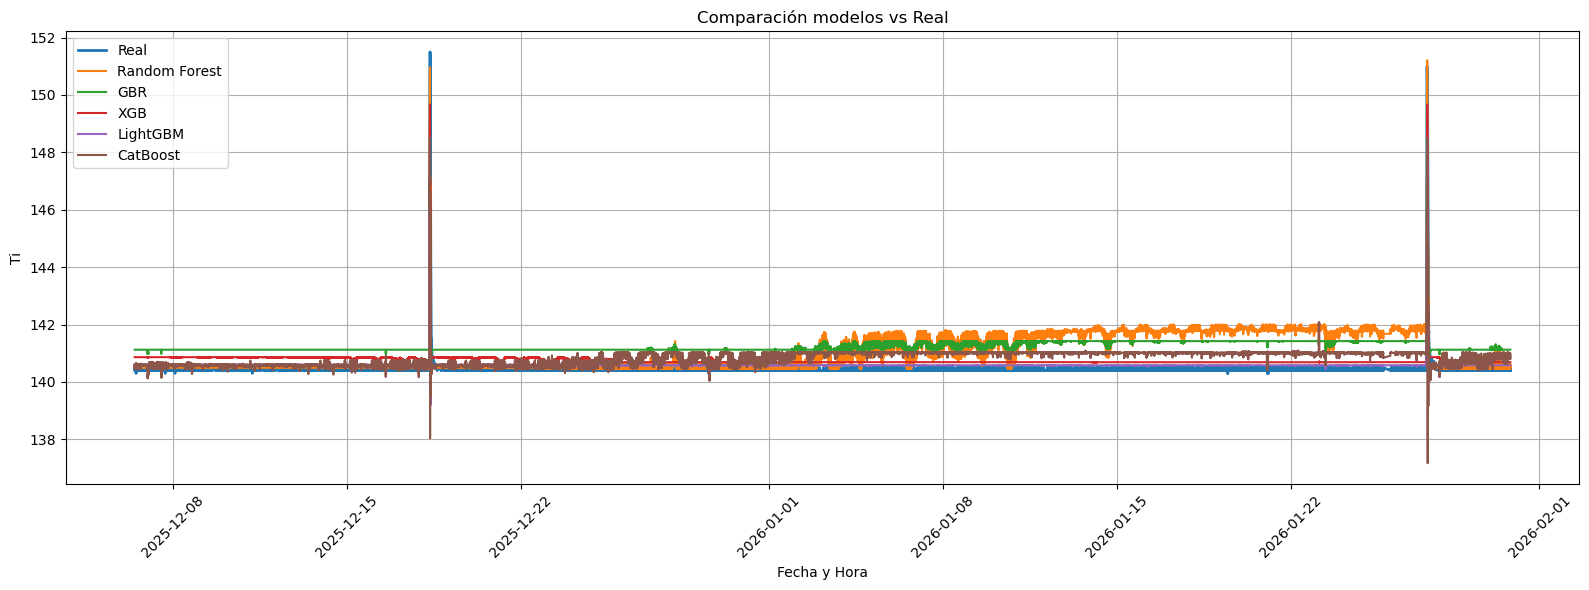

In [250]:
inicio = '2025-01-20 17:00:00'
fin    = '2026-01-30 20:00:00'

mask = (y_test.index >= inicio) & (y_test.index <= fin)

plt.figure(figsize=(16,6))

plt.plot(y_test.index[mask], y_test[mask], label='Real', linewidth=2)
#plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_rf[mask], label='Random Forest')
plt.plot(y_test.index[mask], y_pred_gbr[mask], label='GBR')
plt.plot(y_test.index[mask], y_pred_xgb[mask], label='XGB')
# plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_lgbm[mask], label='LightGBM')
plt.plot(y_test.index[mask], y_pred_cat[mask], label='CatBoost')




plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Fecha y Hora')
plt.ylabel('Ti')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Tm

In [251]:
features = [
    # variables originales
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'RUN FREQ.',
    # AMA temporal
    'AMA_lag_1',
    'AMA_lag_2',
    'AMA_lag_5',
    'AMA_lag_15',
    'AMA_lag_30',
    'AMA_mean_30',
    'AMA_std_30',
    # AVOV temporal
    'AVOV_lag_1',
    'AVOV_lag_2',
    'AVOV_lag_5',
    'AVOV_lag_15',
    'AVOV_lag_30',
    'AVOV_mean_30',
    'AVOV_std_30',
    # Caudal
    'Caudal_lag_1',
    'Caudal_lag_2',
    'Caudal_lag_5',
    'Caudal_lag_15',
    'Caudal_lag_30',
    'Caudal_mean_30',
    'Caudal_std_30',  

]

target = 'Tm'

df_model = df[features + [target]].copy()
X = df_model[features]
y = df_model[target]

In [252]:
# Garantizar que los datos estén ordenados por fecha
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("="*60)

print("TRAIN")

print(f"Inicio : {X_train.index.min()}")
print(f"Fin    : {X_train.index.max()}")
print(f"Datos  : {len(X_train):,}")

print()

print("TEST")

print(f"Inicio : {X_test.index.min()}")
print(f"Fin    : {X_test.index.max()}")
print(f"Datos  : {len(X_test):,}")

print("="*60)

TRAIN
Inicio : 2024-01-01 01:00:30
Fin    : 2025-12-06 10:57:34
Datos  : 748,152

TEST
Inicio : 2025-12-06 10:58:30
Fin    : 2026-04-23 21:42:30
Datos  : 187,038


### Regresion lineal

In [253]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random Forest

In [254]:
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=10,
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST
       Feature  Importance
          AVOA    0.173867
     AMA_lag_1    0.171670
           AMA    0.104648
     AMA_lag_2    0.102483
    AMA_lag_15    0.093596
     AMA_lag_5    0.059453
   AMA_mean_30    0.056942
 Caudal_lag_15    0.036858
  Caudal_lag_1    0.031403
  Caudal_lag_2    0.030491
    AMA_lag_30    0.021647
 Caudal_lag_30    0.016873
 Caudal_std_30    0.014206
Caudal_mean_30    0.013345
  AVOV_mean_30    0.012051
  Caudal_lag_5    0.009779
    AVOV_lag_2    0.006853
          AVOV    0.006846
    AMA_std_30    0.006782
    AVOV_lag_5    0.006384
    AVOV_lag_1    0.005827
   AVOV_lag_15    0.005647
           AMV    0.005493
   AVOV_lag_30    0.004075
     RUN FREQ.    0.002355
   AVOV_std_30    0.000426


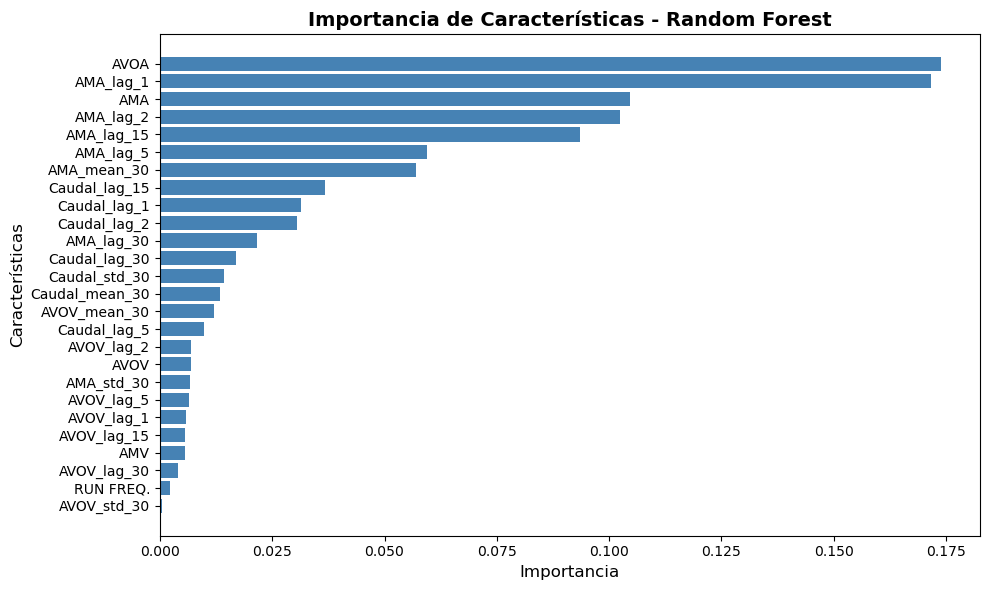


PARTICIPACIÓN PORCENTUAL:
       Feature  Participacion %
          AVOA            17.39
     AMA_lag_1            17.17
           AMA            10.46
     AMA_lag_2            10.25
    AMA_lag_15             9.36
     AMA_lag_5             5.95
   AMA_mean_30             5.69
 Caudal_lag_15             3.69
  Caudal_lag_1             3.14
  Caudal_lag_2             3.05
    AMA_lag_30             2.16
 Caudal_lag_30             1.69
 Caudal_std_30             1.42
Caudal_mean_30             1.33
  AVOV_mean_30             1.21
  Caudal_lag_5             0.98
    AVOV_lag_2             0.69
          AVOV             0.68
    AMA_std_30             0.68
    AVOV_lag_5             0.64
    AVOV_lag_1             0.58
   AVOV_lag_15             0.56
           AMV             0.55
   AVOV_lag_30             0.41
     RUN FREQ.             0.24
   AVOV_std_30             0.04


In [255]:
# Importancia de las características en el modelo Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST")
print("=" * 50)
print(feature_importance.to_string(index=False))
print("=" * 50)

# Gráfico de importancia
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.title('Importancia de Características - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Participación porcentual
feature_importance['Participacion %'] = (feature_importance['Importance'] / feature_importance['Importance'].sum() * 100).round(2)
print("\nPARTICIPACIÓN PORCENTUAL:")
print(feature_importance[['Feature', 'Participacion %']].to_string(index=False))

### Gradient Boosting

In [256]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

### XGBRegresorr

In [257]:
# Modelo
xgb = XGBRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=None,
    max_depth=7,
    learning_rate=0.01,
    random_state=42,
    n_jobs=-1
)
# Entrenar
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

c:\Users\lggom\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:43:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### LightGBM

In [258]:
# Modelo
lgbm = LGBMRegressor(
    subsample=0.8,
    reg_lambda=0,
    reg_alpha=0,
    num_leaves=20,
    n_estimators=100,
    min_child_weight=5,
    min_child_samples=20,
    max_depth=5,
    learning_rate=0.05,
    feature_fraction=0.7,
    colsample_bytree=1.0,
    bagging_fraction=0.7,
    random_state=42,
    n_jobs=-1
)
# Entrenar
lgbm.fit(X_train, y_train)
# Predicción
y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,031710 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5141
[LightGBM] [Info] Number of data points in the train set: 748152, number of used features: 26
[LightGBM] [Info] Start training from score 171,322960
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Curre

### Catboost

In [259]:
# Modelo
cat = CatBoostRegressor(
    subsample=0.9,
    min_child_samples=20,
    learning_rate=0.1,
    l2_leaf_reg=10,
    iterations=500,
    depth=3,
    colsample_bylevel=0.7,
    border_count=32
)

# Entrenar
cat.fit(X_train, y_train)
# Predicción
y_pred_cat = cat.predict(X_test)

0:	learn: 17.1310264	total: 26.4ms	remaining: 13.2s
1:	learn: 15.6757002	total: 51.4ms	remaining: 12.8s
2:	learn: 14.3950933	total: 75ms	remaining: 12.4s
3:	learn: 13.2489754	total: 98.7ms	remaining: 12.2s
4:	learn: 12.2508140	total: 123ms	remaining: 12.2s
5:	learn: 11.3295826	total: 149ms	remaining: 12.3s
6:	learn: 10.5287502	total: 174ms	remaining: 12.2s
7:	learn: 9.8314916	total: 201ms	remaining: 12.4s
8:	learn: 9.2193922	total: 226ms	remaining: 12.3s
9:	learn: 8.6911512	total: 252ms	remaining: 12.4s
10:	learn: 8.2359390	total: 279ms	remaining: 12.4s
11:	learn: 7.8360171	total: 303ms	remaining: 12.3s
12:	learn: 7.4592190	total: 326ms	remaining: 12.2s
13:	learn: 7.1627055	total: 352ms	remaining: 12.2s
14:	learn: 6.8902337	total: 376ms	remaining: 12.1s
15:	learn: 6.6655181	total: 401ms	remaining: 12.1s
16:	learn: 6.4416011	total: 425ms	remaining: 12.1s
17:	learn: 6.2609346	total: 448ms	remaining: 12s
18:	learn: 6.0989436	total: 473ms	remaining: 12s
19:	learn: 5.9397533	total: 495ms	re

### Evaluacion

In [260]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

evaluar(y_test, y_pred_lr,  "Linear Regression")
evaluar(y_test, y_pred_rf,  "Random Forest")
evaluar(y_test, y_pred_gbr, "Gradient Boosting")
evaluar(y_test, y_pred_xgb, "XGBoost")
evaluar(y_test, y_pred_lgbm, "LightGBM")
evaluar(y_test, y_pred_cat, "CatBoost")

Linear Regression -> RMSE: 5.350 | R2: -0.191
Random Forest -> RMSE: 4.334 | R2: 0.219
Gradient Boosting -> RMSE: 14.859 | R2: -8.185
XGBoost -> RMSE: 7.341 | R2: -1.242
LightGBM -> RMSE: 10.603 | R2: -3.677
CatBoost -> RMSE: 7.073 | R2: -1.081


In [261]:
# Crear tabla de evaluación
resultados = []

modelos = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm,
    "CatBoost": y_pred_cat
}

for nombre, predicciones in modelos.items():
    mse = mean_squared_error(y_test, predicciones)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    resultados.append({
        "Modelo": nombre,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R² Score": round(r2, 4),
        "MSE": round(mse, 4)
    })

tabla_evaluacion = pd.DataFrame(resultados)
tabla_evaluacion

,Modelo,RMSE,MAE,R² Score,MSE
0,Linear Regression,5.3503,4.8613,-0.1908,28.6257
1,Random Forest,4.3340,3.3000,0.2186,18.7838
2,Gradient Boosting,14.8595,13.0298,-8.1851,220.8034
3,XGBoost,7.3411,6.5693,-1.2418,53.8912
4,LightGBM,10.6029,8.9499,-3.6766,112.4222
5,CatBoost,7.0730,5.7721,-1.0810,50.0270


### Grafica

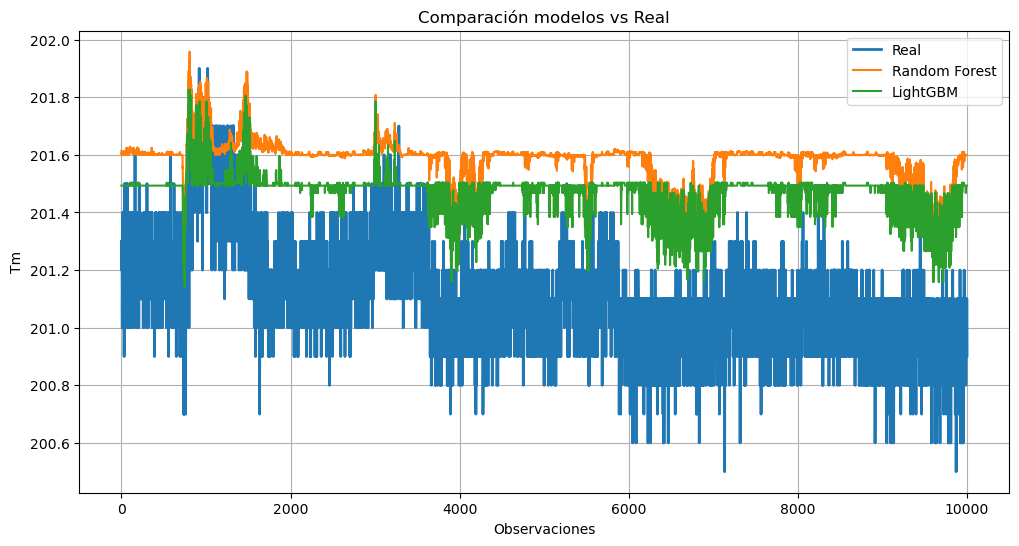

In [262]:
plt.figure(figsize=(12,6))

window_max=10000

plt.plot(y_test.values[:window_max], label='Real', linewidth=2)
#plt.plot(y_pred_lr[:window_max], label='Linear')
plt.plot(y_pred_rf[:window_max], label='Random Forest')
#plt.plot(y_pred_gbr[:window_max], label='GBR')
#plt.plot(y_pred_xgb[:window_max], label='XGB')
plt.plot(y_pred_lgbm[:window_max], label='LightGBM')
#plt.plot(y_pred_cat[:window_max], label='CatBoost')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Observaciones')
plt.ylabel('Tm')
plt.grid(True)

plt.show()

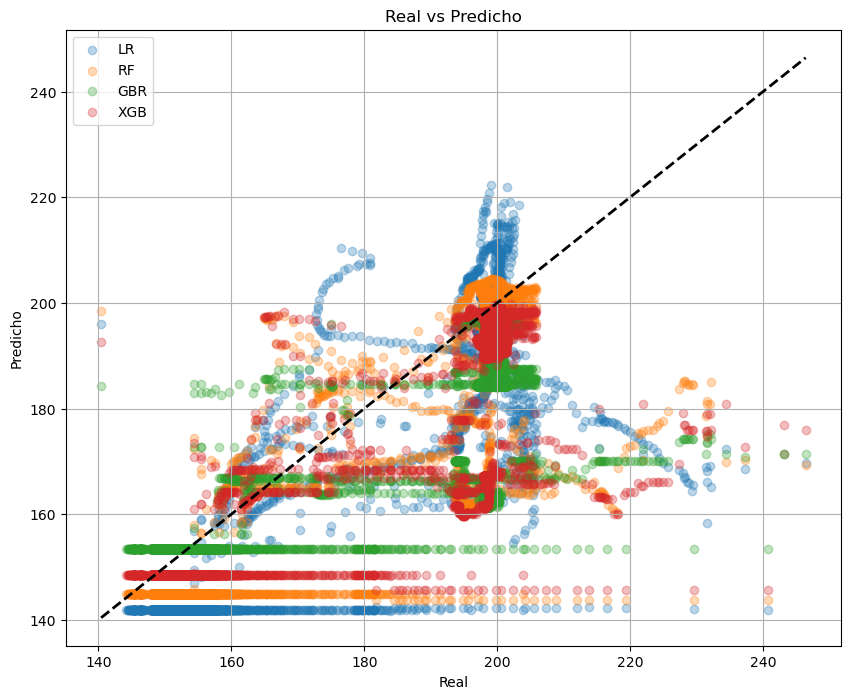

In [263]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='LR')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='RF')
#plt.scatter(y_test, y_pred_svr, alpha=0.3, label='SVR')
plt.scatter(y_test, y_pred_gbr, alpha=0.3, label='GBR')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGB')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)

plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.grid(True)

plt.show()

In [264]:
print("Fecha inicial:", y_test.index.min())
print("Fecha final:", y_test.index.max())

Fecha inicial: 2025-12-06 10:58:30
Fecha final: 2026-04-23 21:42:30


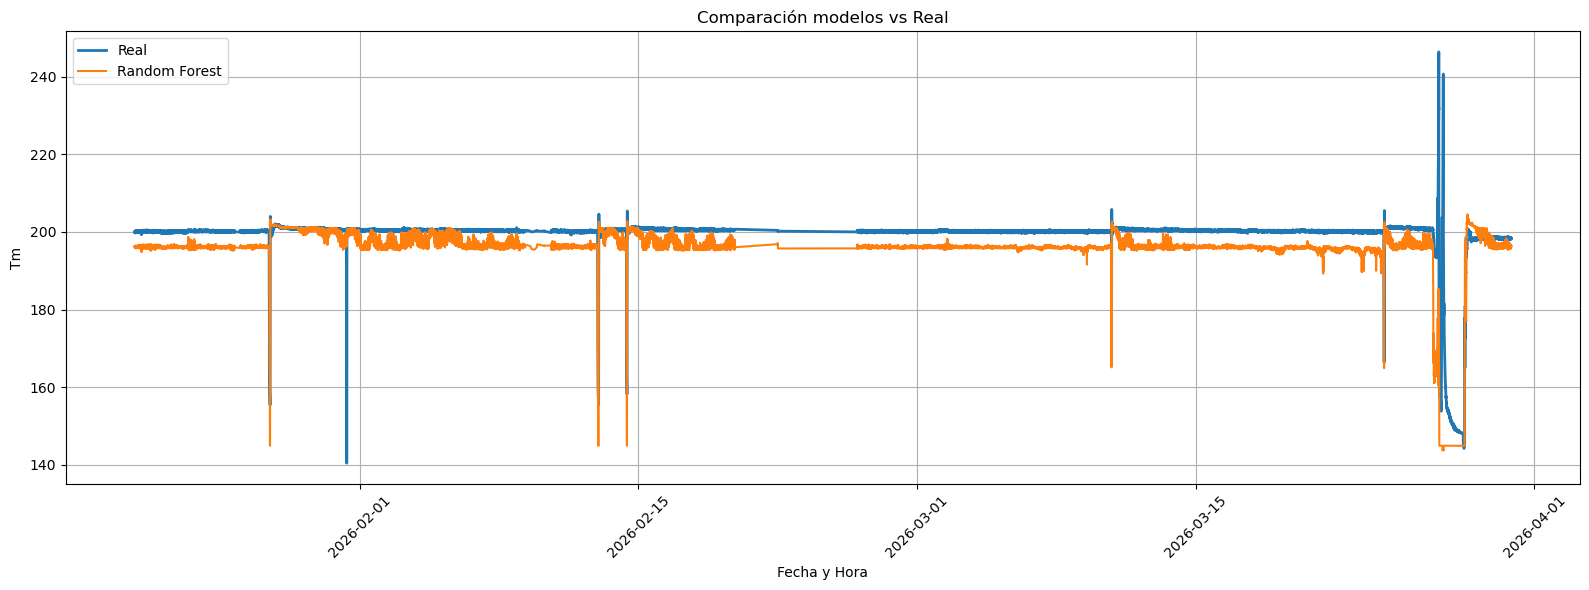

In [265]:
inicio = '2026-01-20 17:00:00'
fin    = '2026-03-30 20:00:00'

mask = (y_test.index >= inicio) & (y_test.index <= fin)

plt.figure(figsize=(16,6))

plt.plot(y_test.index[mask], y_test[mask], label='Real', linewidth=2)
#plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_rf[mask], label='Random Forest')
#plt.plot(y_test.index[mask], y_pred_gbr[mask], label='GBR')
#plt.plot(y_test.index[mask], y_pred_xgb[mask], label='XGB')
# plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
#plt.plot(y_test.index[mask], y_pred_lgbm[mask], label='LightGBM')
#plt.plot(y_test.index[mask], y_pred_cat[mask], label='CatBoost')




plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Fecha y Hora')
plt.ylabel('Tm')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Vx

In [67]:
features = [
    # variables originales
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'RUN FREQ.',
    # AMA temporal
    'AMA_lag_1',
    'AMA_lag_2',
    'AMA_lag_5',
    'AMA_lag_15',
    'AMA_lag_30',
    'AMA_mean_30',
    'AMA_std_30',
    # AVOV temporal
    'AVOV_lag_1',
    'AVOV_lag_2',
    'AVOV_lag_5',
    'AVOV_lag_15',
    'AVOV_lag_30',
    'AVOV_mean_30',
    'AVOV_std_30',
    # VX temporal
    'VX_lag_31',
    'VX_lag_32',
    'VX_lag_35',
    'VX_lag_45',
    'VX_lag_60',
    'VX_mean_31_60',
    'VX_std_31_60'
]

target = 'VX'

df_model = df[features + [target]].copy()
X = df_model[features]
y = df_model[target]

In [68]:
# Garantizar que los datos estén ordenados por fecha
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("="*60)

print("TRAIN")

print(f"Inicio : {X_train.index.min()}")
print(f"Fin    : {X_train.index.max()}")
print(f"Datos  : {len(X_train):,}")

print()

print("TEST")

print(f"Inicio : {X_test.index.min()}")
print(f"Fin    : {X_test.index.max()}")
print(f"Datos  : {len(X_test):,}")

print("="*60)

TRAIN
Inicio : 2024-01-01 01:00:30
Fin    : 2025-12-06 09:46:30
Datos  : 749,022

TEST
Inicio : 2025-12-06 09:47:30
Fin    : 2026-04-23 21:42:30
Datos  : 187,256


### Regresion lineal

In [69]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random Forest

In [70]:
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=10,
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST
      Feature  Importance
VX_mean_31_60    0.246575
    VX_lag_31    0.109988
    VX_lag_35    0.095498
    VX_lag_32    0.088893
    VX_lag_60    0.074978
    VX_lag_45    0.069061
    AMA_lag_1    0.059316
         AVOA    0.049618
          AMA    0.031081
  AMA_mean_30    0.027951
    AMA_lag_5    0.027412
    AMA_lag_2    0.026913
   AMA_lag_15    0.011711
         AVOV    0.010540
   AMA_std_30    0.010220
   AVOV_lag_1    0.008909
   AMA_lag_30    0.007558
          AMV    0.007361
    RUN FREQ.    0.007094
  AVOV_lag_15    0.005450
   AVOV_lag_2    0.005118
  AVOV_lag_30    0.005072
   AVOV_lag_5    0.004925
 VX_std_31_60    0.004374
 AVOV_mean_30    0.003850
  AVOV_std_30    0.000533


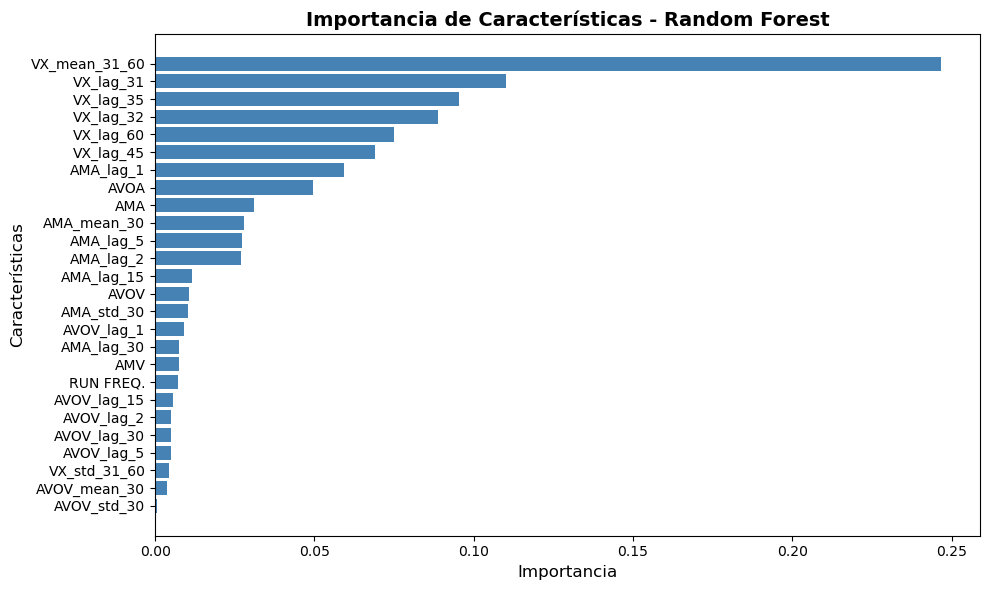


PARTICIPACIÓN PORCENTUAL:
      Feature  Participacion %
VX_mean_31_60            24.66
    VX_lag_31            11.00
    VX_lag_35             9.55
    VX_lag_32             8.89
    VX_lag_60             7.50
    VX_lag_45             6.91
    AMA_lag_1             5.93
         AVOA             4.96
          AMA             3.11
  AMA_mean_30             2.80
    AMA_lag_5             2.74
    AMA_lag_2             2.69
   AMA_lag_15             1.17
         AVOV             1.05
   AMA_std_30             1.02
   AVOV_lag_1             0.89
   AMA_lag_30             0.76
          AMV             0.74
    RUN FREQ.             0.71
  AVOV_lag_15             0.54
   AVOV_lag_2             0.51
  AVOV_lag_30             0.51
   AVOV_lag_5             0.49
 VX_std_31_60             0.44
 AVOV_mean_30             0.39
  AVOV_std_30             0.05


In [71]:
# Importancia de las características en el modelo Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST")
print("=" * 50)
print(feature_importance.to_string(index=False))
print("=" * 50)

# Gráfico de importancia
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.title('Importancia de Características - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Participación porcentual
feature_importance['Participacion %'] = (feature_importance['Importance'] / feature_importance['Importance'].sum() * 100).round(2)
print("\nPARTICIPACIÓN PORCENTUAL:")
print(feature_importance[['Feature', 'Participacion %']].to_string(index=False))

### Gradient Boosting

In [72]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

### XGBRegresorr

In [73]:
# Modelo
xgb = XGBRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=None,
    max_depth=7,
    learning_rate=0.01,
    random_state=42,
    n_jobs=-1
)
# Entrenar
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

c:\Users\lggom\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:20:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### LightGBM

In [74]:
# Modelo
lgbm = LGBMRegressor(
    subsample=0.8,
    reg_lambda=0,
    reg_alpha=0,
    num_leaves=20,
    n_estimators=100,
    min_child_weight=5,
    min_child_samples=20,
    max_depth=5,
    learning_rate=0.05,
    feature_fraction=0.7,
    colsample_bytree=1.0,
    bagging_fraction=0.7,
    random_state=42,
    n_jobs=-1
)
# Entrenar
lgbm.fit(X_train, y_train)
# Predicción
y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008626 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5216
[LightGBM] [Info] Number of data points in the train set: 749022, number of used features: 26
[LightGBM] [Info] Start training from score 0.208966
[LightGBM] [Warning] feature_fr

### Catboost

In [75]:
# Modelo
cat = CatBoostRegressor(
    subsample=0.9,
    min_child_samples=20,
    learning_rate=0.1,
    l2_leaf_reg=10,
    iterations=500,
    depth=3,
    colsample_bylevel=0.7,
    border_count=32
)

# Entrenar
cat.fit(X_train, y_train)
# Predicción
y_pred_cat = cat.predict(X_test)

0:	learn: 0.0628592	total: 26.2ms	remaining: 13.1s
1:	learn: 0.0589793	total: 54.3ms	remaining: 13.5s
2:	learn: 0.0556153	total: 80ms	remaining: 13.3s
3:	learn: 0.0525722	total: 106ms	remaining: 13.2s
4:	learn: 0.0498896	total: 131ms	remaining: 13s
5:	learn: 0.0476769	total: 160ms	remaining: 13.2s
6:	learn: 0.0456308	total: 187ms	remaining: 13.1s
7:	learn: 0.0438598	total: 213ms	remaining: 13.1s
8:	learn: 0.0423302	total: 239ms	remaining: 13s
9:	learn: 0.0410027	total: 267ms	remaining: 13.1s
10:	learn: 0.0399027	total: 297ms	remaining: 13.2s
11:	learn: 0.0389734	total: 328ms	remaining: 13.3s
12:	learn: 0.0382078	total: 358ms	remaining: 13.4s
13:	learn: 0.0374641	total: 387ms	remaining: 13.4s
14:	learn: 0.0368480	total: 413ms	remaining: 13.4s
15:	learn: 0.0363373	total: 443ms	remaining: 13.4s
16:	learn: 0.0358650	total: 471ms	remaining: 13.4s
17:	learn: 0.0355156	total: 497ms	remaining: 13.3s
18:	learn: 0.0351850	total: 527ms	remaining: 13.3s
19:	learn: 0.0349130	total: 558ms	remaining:

### Evaluacion

In [76]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

evaluar(y_test, y_pred_lr,  "Linear Regression")
evaluar(y_test, y_pred_rf,  "Random Forest")
evaluar(y_test, y_pred_gbr, "Gradient Boosting")
evaluar(y_test, y_pred_xgb, "XGBoost")
evaluar(y_test, y_pred_lgbm, "LightGBM")
evaluar(y_test, y_pred_cat, "CatBoost")

Linear Regression -> RMSE: 0.049 | R2: 0.712
Random Forest -> RMSE: 0.070 | R2: 0.418
Gradient Boosting -> RMSE: 0.066 | R2: 0.487
XGBoost -> RMSE: 0.064 | R2: 0.518
LightGBM -> RMSE: 0.062 | R2: 0.549
CatBoost -> RMSE: 0.063 | R2: 0.527


In [77]:
# Crear tabla de evaluación
resultados = []

modelos = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm,
    "CatBoost": y_pred_cat
}

for nombre, predicciones in modelos.items():
    mse = mean_squared_error(y_test, predicciones)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    resultados.append({
        "Modelo": nombre,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R² Score": round(r2, 4),
        "MSE": round(mse, 4)
    })

tabla_evaluacion = pd.DataFrame(resultados)
tabla_evaluacion

,Modelo,RMSE,MAE,R² Score,MSE
0,Linear Regression,0.0495,0.0335,0.7121,0.0024
1,Random Forest,0.0704,0.0408,0.4180,0.0050
2,Gradient Boosting,0.0661,0.0392,0.4866,0.0044
3,XGBoost,0.0641,0.0383,0.5176,0.0041
4,LightGBM,0.0619,0.0375,0.5492,0.0038
5,CatBoost,0.0634,0.0380,0.5268,0.0040


### Grafica

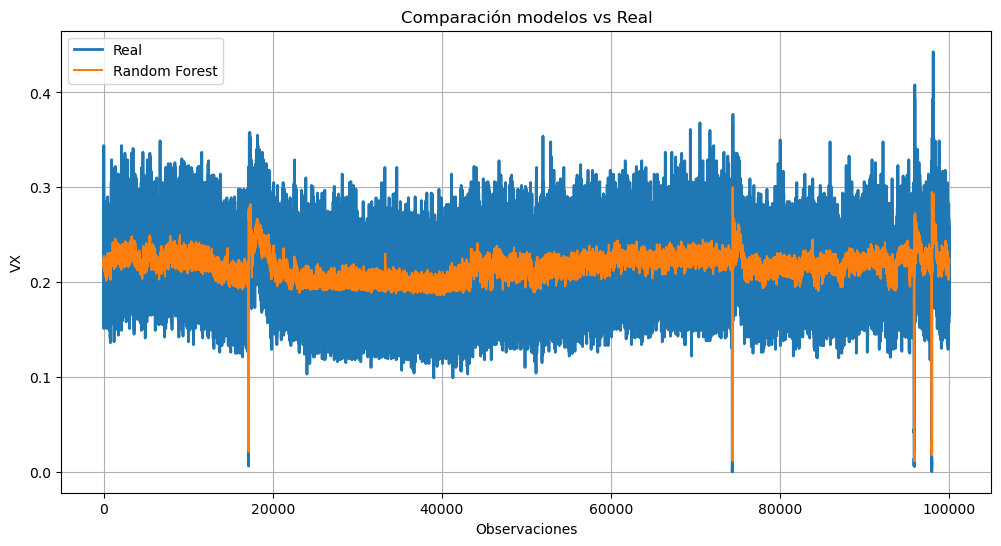

In [78]:
plt.figure(figsize=(12,6))

window_max=100000

plt.plot(y_test.values[:window_max], label='Real', linewidth=2)
#plt.plot(y_pred_lr[:window_max], label='Linear')
plt.plot(y_pred_rf[:window_max], label='Random Forest')
#plt.plot(y_pred_gbr[:window_max], label='GBR')
#plt.plot(y_pred_xgb[:window_max], label='XGB')
#plt.plot(y_pred_lgbm[:window_max], label='LightGBM')
#plt.plot(y_pred_cat[:window_max], label='CatBoost')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Observaciones')
plt.ylabel('VX')
plt.grid(True)

plt.show()

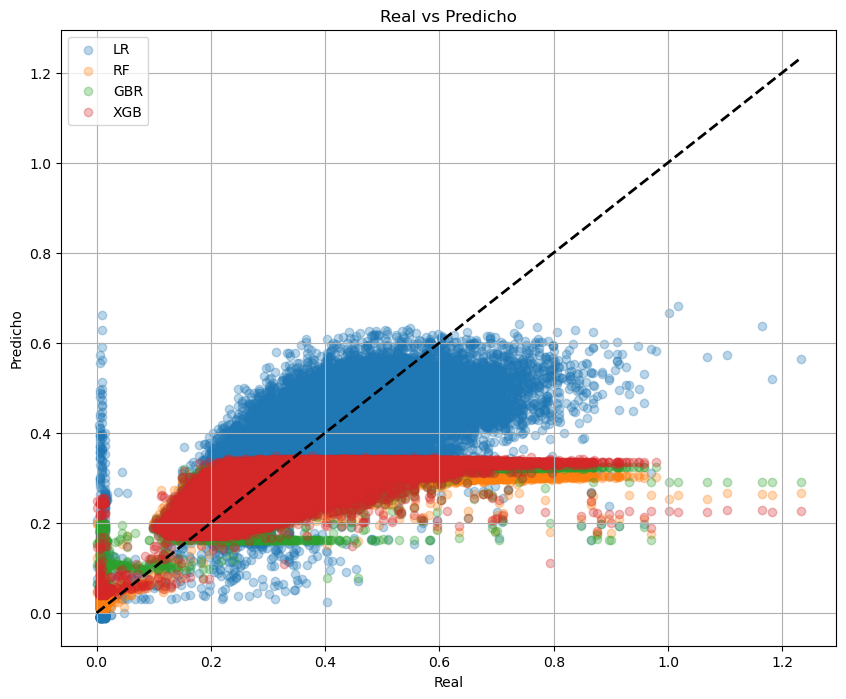

In [79]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='LR')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='RF')
#plt.scatter(y_test, y_pred_svr, alpha=0.3, label='SVR')
plt.scatter(y_test, y_pred_gbr, alpha=0.3, label='GBR')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGB')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)

plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.grid(True)

plt.show()

In [80]:
print("Fecha inicial:", y_test.index.min())
print("Fecha final:", y_test.index.max())

Fecha inicial: 2025-12-06 09:47:30
Fecha final: 2026-04-23 21:42:30


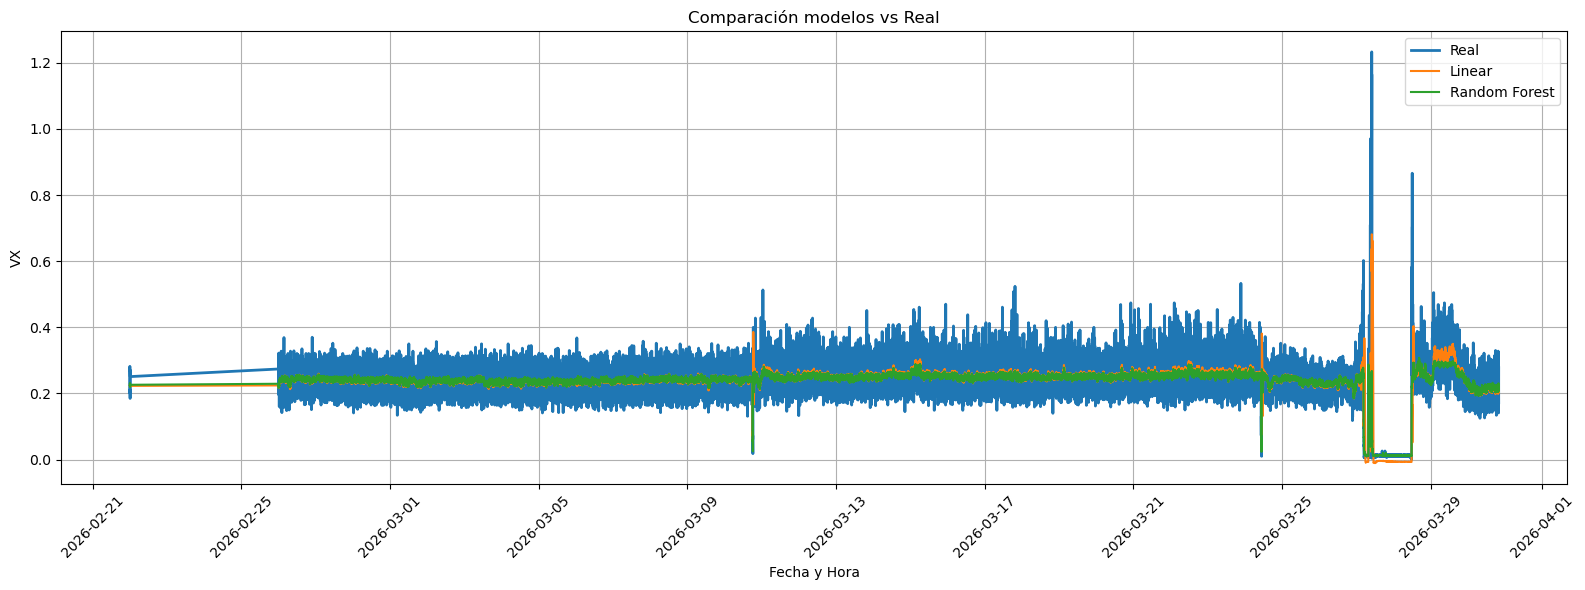

In [81]:
inicio = '2026-02-20 17:00:00'
fin    = '2026-03-30 20:00:00'

mask = (y_test.index >= inicio) & (y_test.index <= fin)

plt.figure(figsize=(16,6))

plt.plot(y_test.index[mask], y_test[mask], label='Real', linewidth=2)
plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_rf[mask], label='Random Forest')
#plt.plot(y_test.index[mask], y_pred_gbr[mask], label='GBR')
#plt.plot(y_test.index[mask], y_pred_xgb[mask], label='XGB')
# plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
#plt.plot(y_test.index[mask], y_pred_lgbm[mask], label='LightGBM')
#plt.plot(y_test.index[mask], y_pred_cat[mask], label='CatBoost')




plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Fecha y Hora')
plt.ylabel('VX')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Revision cruzada

In [ ]:
# =====================================================
# VALIDACIÓN CRUZADA TEMPORAL Random Forest
# =====================================================

tscv = TimeSeriesSplit(n_splits=5)

results = []

fold = 1

for train_index, test_index in tscv.split(X):

    # división temporal
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # =================================================
    # MODELO RANDOM FOREST
    # =================================================

    #model = RandomForestRegressor(n_estimators=100, random_state=42)
    model = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=20,
    random_state=42,
    n_jobs=-1
    )
    # entrenamiento
    model.fit(X_train, y_train)

    # predicción
    y_pred = model.predict(X_test)

    # =================================================
    # MÉTRICAS
    # =================================================

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    # fechas del fold
    train_dates = X_train.index
    test_dates = X_test.index

    # guardar resultados
    results.append({
        'Fold': fold,

        'Train Start': train_dates.min(),
        'Train End': train_dates.max(),

        'Test Start': test_dates.min(),
        'Test End': test_dates.max(),

        'Train Size': len(train_index),
        'Test Size': len(test_index),

        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

    # =================================================
    # IMPRESIÓN
    # =================================================

    print("\n" + "="*60)

    print(f"FOLD {fold}")

    print("-"*60)

    print(f"TRAIN:")
    print(f"Inicio: {train_dates.min()}")
    print(f"Fin   : {train_dates.max()}")
    print(f"Datos : {len(train_index):,}")

    print()

    print(f"TEST:")
    print(f"Inicio: {test_dates.min()}")
    print(f"Fin   : {test_dates.max()}")
    print(f"Datos : {len(test_index):,}")

    print()

    print("MÉTRICAS:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    fold += 1

# =====================================================
# RESUMEN FINAL
# =====================================================

results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("RESUMEN VALIDACIÓN CRUZADA")
print("="*60)

print(results_df)

print("\nPROMEDIO MÉTRICAS")

print(
    results_df[['MAE', 'RMSE', 'R2']].mean()
)

# Hyperpareter tunning

## Random forest Hypertunning

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,                      # número de combinaciones aleatorias
    cv=tscv,                        # validación temporal
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Ejecutar búsqueda aleatoria
random_search.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search.best_params_)
best_rf = random_search.best_estimator_

In [ ]:
# Evaluar modelo afinado
y_pred_rf = best_rf.predict(X_test)
evaluar(y_test, y_pred_rf, "Random Forest Tuned")

## Gradient boosting hypertunning

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
gbr = GradientBoostingRegressor(
    random_state=42
)
param_dist = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 1.0],
    'max_features': ['sqrt', None]
}

In [ ]:
random_search_gbr = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search_gbr.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_gbr.best_params_)
best_gbr = random_search_gbr.best_estimator_

In [ ]:
y_pred_gbr = best_gbr.predict(X_test)
evaluar(y_test, y_pred_gbr, "Gradient Boosting Tuned")

## XGBRegresorr hypertuning

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

In [ ]:
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search_xgb.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_xgb.best_params_)
best_xgb = random_search_xgb.best_estimator_

In [ ]:
y_pred_xgb = best_xgb.predict(X_test)
evaluar(y_test, y_pred_xgb, "XGBoost Tuned")

## LightGBM

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
lgbm = LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'num_leaves': [20, 30, 40, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'min_child_samples': [5, 10, 20],
    'reg_alpha': [0, 0.01, 0.1, 1.0],
    'reg_lambda': [0, 0.1, 1.0, 10.0],
    'feature_fraction': [0.7, 0.8, 1.0],
    'bagging_fraction': [0.7, 0.8, 1.0]
}

In [ ]:
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=20,  # Aumentado a 20 por la mayor cantidad de parámetros
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search_lgbm.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_lgbm.best_params_)
best_lgbm = random_search_lgbm.best_estimator_

In [ ]:
y_pred_lgbm = best_lgbm.predict(X_test)
evaluar(y_test, y_pred_lgbm, "LightGBM Tuned")

## Catboost

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
cat = CatBoostRegressor(
    loss_function='RMSE',
    random_state=42,
    verbose=0,
    thread_count=-1
)
param_dist = {
    'iterations': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 5, 7, 9],
    'l2_leaf_reg': [1, 3, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bylevel': [0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [5, 10, 20],
    'border_count': [32, 64, 128],
    'use_best_model': [False, True]
}

In [ ]:
random_search_cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search_cat.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_cat.best_params_)
best_cat = random_search_cat.best_estimator_

In [ ]:
y_pred_cat = best_cat.predict(X_test)
evaluar(y_test, y_pred_cat, "CatBoost Tuned")